# Project : Flu Shot Learning: Predict H1N1 and Seasonal Flu Vaccines

# Project Problem Definition:
* The goal is to predict how likely individuals are to receive their H1N1 and seasonal vaccines.

In [1]:
#Basic models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline   
# to show all matplotlib plots inside jupyter notebook
import math
import seaborn as sns
from scipy.stats import ttest_ind

In [2]:
# Load the data
features = pd.read_csv("features.csv")
labels = pd.read_csv('labels.csv')
pd.set_option("display.max_columns",None)

In [3]:
features

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,1.0,1.0,5.0,2.0,2.0,65+ Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,NaN,NaN
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,4.0,2.0,2.0,5.0,1.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,4.0,4.0,2.0,5.0,4.0,2.0,55 - 64 Years,Some College,White,Female,NaN,Not Married,Own,NaN,lzgpxyit,"MSA, Not Principle City",0.0,0.0,NaN,NaN
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,2.0,2.0,1.0,2.0,18 - 34 Years,Some College,Hispanic,Female,"<= $75,000, Above Poverty",Married,Rent,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg


In [4]:
labels #target variables

,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1
2,2,0,0
3,3,0,1
4,4,0,0
...,...,...,...
26702,26702,0,0
26703,26703,0,0
26704,26704,0,1
26705,26705,0,0


In [5]:
# Merging both the files keeping "respondent_id" as the key
data = features.merge(labels, on='respondent_id')

In [6]:
# Merged file
data

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,1.0,1.0,5.0,2.0,2.0,65+ Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,NaN,NaN,0,0
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,4.0,2.0,2.0,5.0,1.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea,0,0
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,4.0,4.0,2.0,5.0,4.0,2.0,55 - 64 Years,Some College,White,Female,NaN,Not Married,Own,NaN,lzgpxyit,"MSA, Not Principle City",0.0,0.0,NaN,NaN,0,1
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,2.0,2.0,1.0,2.0,18 - 34 Years,Some College,Hispanic,Female,"<= $75,000, Above Poverty",Married,Rent,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg,0,0


### Domain Analysis  


The features can on the basis of diffferent factors and explained as follows:
1. Based on risk & Knowlegde 
* h1n1_concern : mentions regarding the concern of the person about H1N1, thus higher concerns means higher chances of vaccination.
* h1n1_knowledge : regarding the knowledge of the H1N1 vaccine, thus higher knowledge means higher chances of getting vaccine due to the knowlegde.
 
2. Based on Preventive behaviour
* behavioral_antiviral_meds : indicates regarding the past antiviral medication usage.
* behavioral_avoidance : shows cautious behaviour by avoiding sick people.
* behavioral_face_mask : indicates the understanding of the risk by mask purchasing.
* behavioral_wash_hands : shows good preventive habits.
* behavioral_large_gatherings : shows reduction in risk by reducing gatherings.
* behavioral_outside_home : again indicates cautious by limiting outside contact.
* behavioral_touch_face : shows discipline by avoiding the face touch.
Above features strongly reflect vaccine acceptance.

3. Based on Recommendation 
* doctor_recc_h1n1 : indicates doctors's recommendation which is the __strongest predictor__.
* doctor_recc_seasonal : same applicable for seasonal flu, thus again the __strongest predictor__
Above features strongly decided the vaccination decisions.

4. Based on Health Condition
* chronic_med_condition : person with chronic health condition are more likely to get vaccinated.
* child_under_6_months : Under 6 years is a sensitive age therefore more probe toward getting vaccinated.
* health_worker : they are more exposed thus more required to get vaccinated.
* health_insurance : provides access towards healthcare thus more tendency towards vaccination.

5. Based on Opinion
* opinion_h1n1_vacc_effective : more the belief in effectiveness greater the influence of vaccination.
* opinion_h1n1_risk : to understand the risk without vaccination.
* opinion_h1n1_sick_from_vacc : considering the side effects of vaccination, so higher vaccination leads to lower vaccination.
* opinion_seas_vacc_effective, opinion_seas_risk, opinion_seas_sick_from_vacc  : same as above, but here for h1n1.
Above features shows psychological and attitudinal factors thereby affecting the decisions.

6. Based on Demography
* age_group : higher chances of vaccination are there for older people.
* education : higher knowledge leads to more information regarding the vaccination.
* race : shows the differences based on the population level.
* sex : behaviour of getting vaccinated may differ based on the sex.
* income_poverty : the level of income affects the behaviour towards getitng vaccinated.
* marital_status, rent_or_own, employment_status : indicates the influence based on responsibility, economic stability and employment.
Above features represents social determinants of health.

7. Based on Geography
* hhs_geo_region : some place may have higher chances of getting flu or better outreach of vaccination.
* census_msa : accessibility may differ based on urban and rural.

8. Based on Household
* household_adults : higher the family, more is the risk of getting exposed.
* household_children : more children refers to higher concern of illness.

9. Based on Employment
* employment_industry : industries more related to the field of getting more exposed to flu have higher need of vaccination
* employment_occupation : role type can affect the employer requirements.

# Basic Check:

In [7]:
data.head() #displays first 5 rows

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [8]:
data.shape # gives total number of rows and columns

(26707, 38)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

* The data consists of total 26706 rows and 38 columns.
* The datatypes included in the dataframe are int64, float64 and object.

In [10]:
# statistical description
data.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
count,26707.000000,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,24547.000000,24547.000000,25736.000000,25887.000000,25903.000000,14433.00000,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000,26707.000000
mean,13353.000000,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,0.220312,0.329735,0.283261,0.082590,0.111918,0.87972,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,0.212454,0.465608
std,7709.791156,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,0.414466,0.470126,0.450591,0.275266,0.315271,0.32530,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,0.409052,0.498825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,6676.500000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,13353.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,20029.500000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.00000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,26706.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,1.000000


In [11]:
#Entire data
data

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,1.0,1.0,5.0,2.0,2.0,65+ Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,NaN,NaN,0,0
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,4.0,2.0,2.0,5.0,1.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea,0,0
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,4.0,4.0,2.0,5.0,4.0,2.0,55 - 64 Years,Some College,White,Female,NaN,Not Married,Own,NaN,lzgpxyit,"MSA, Not Principle City",0.0,0.0,NaN,NaN,0,1
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,2.0,2.0,1.0,2.0,18 - 34 Years,Some College,Hispanic,Female,"<= $75,000, Above Poverty",Married,Rent,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg,0,0


# EDA (Exploratory Data Analysis):

In [19]:
# Numeric column
num_cols = data.select_dtypes(include=['int64','float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

In [20]:
num_cols

Index(['respondent_id', 'h1n1_concern', 'h1n1_knowledge',
       'behavioral_antiviral_meds', 'behavioral_avoidance',
       'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults',
       'household_children', 'h1n1_vaccine', 'seasonal_vaccine'],
      dtype='object')

In [21]:
# To drop the respondent_id column
num_cols = num_cols.drop('respondent_id')

In [22]:
num_cols

Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults',
       'household_children', 'h1n1_vaccine', 'seasonal_vaccine'],
      dtype='object')

In [23]:
len(num_cols)

25

In [24]:
cat_cols

Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry', 'employment_occupation'],
      dtype='object')

In [25]:
len(cat_cols)

12

#### Checking the balance of data

In [26]:
print(data['h1n1_vaccine'].value_counts())
print(data['h1n1_vaccine'].value_counts(normalize=True) * 100)

print(data['seasonal_vaccine'].value_counts())
print(data['seasonal_vaccine'].value_counts(normalize=True) * 100)


h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64
h1n1_vaccine
0    78.754634
1    21.245366
Name: proportion, dtype: float64
seasonal_vaccine
0    14272
1    12435
Name: count, dtype: int64
seasonal_vaccine
0    53.439173
1    46.560827
Name: proportion, dtype: float64


* For the h1n1_vaccine, the dataset is imbalanced.
* For the seasonal_vaccine, the dataset is balanced.


### Univariate Analysis:

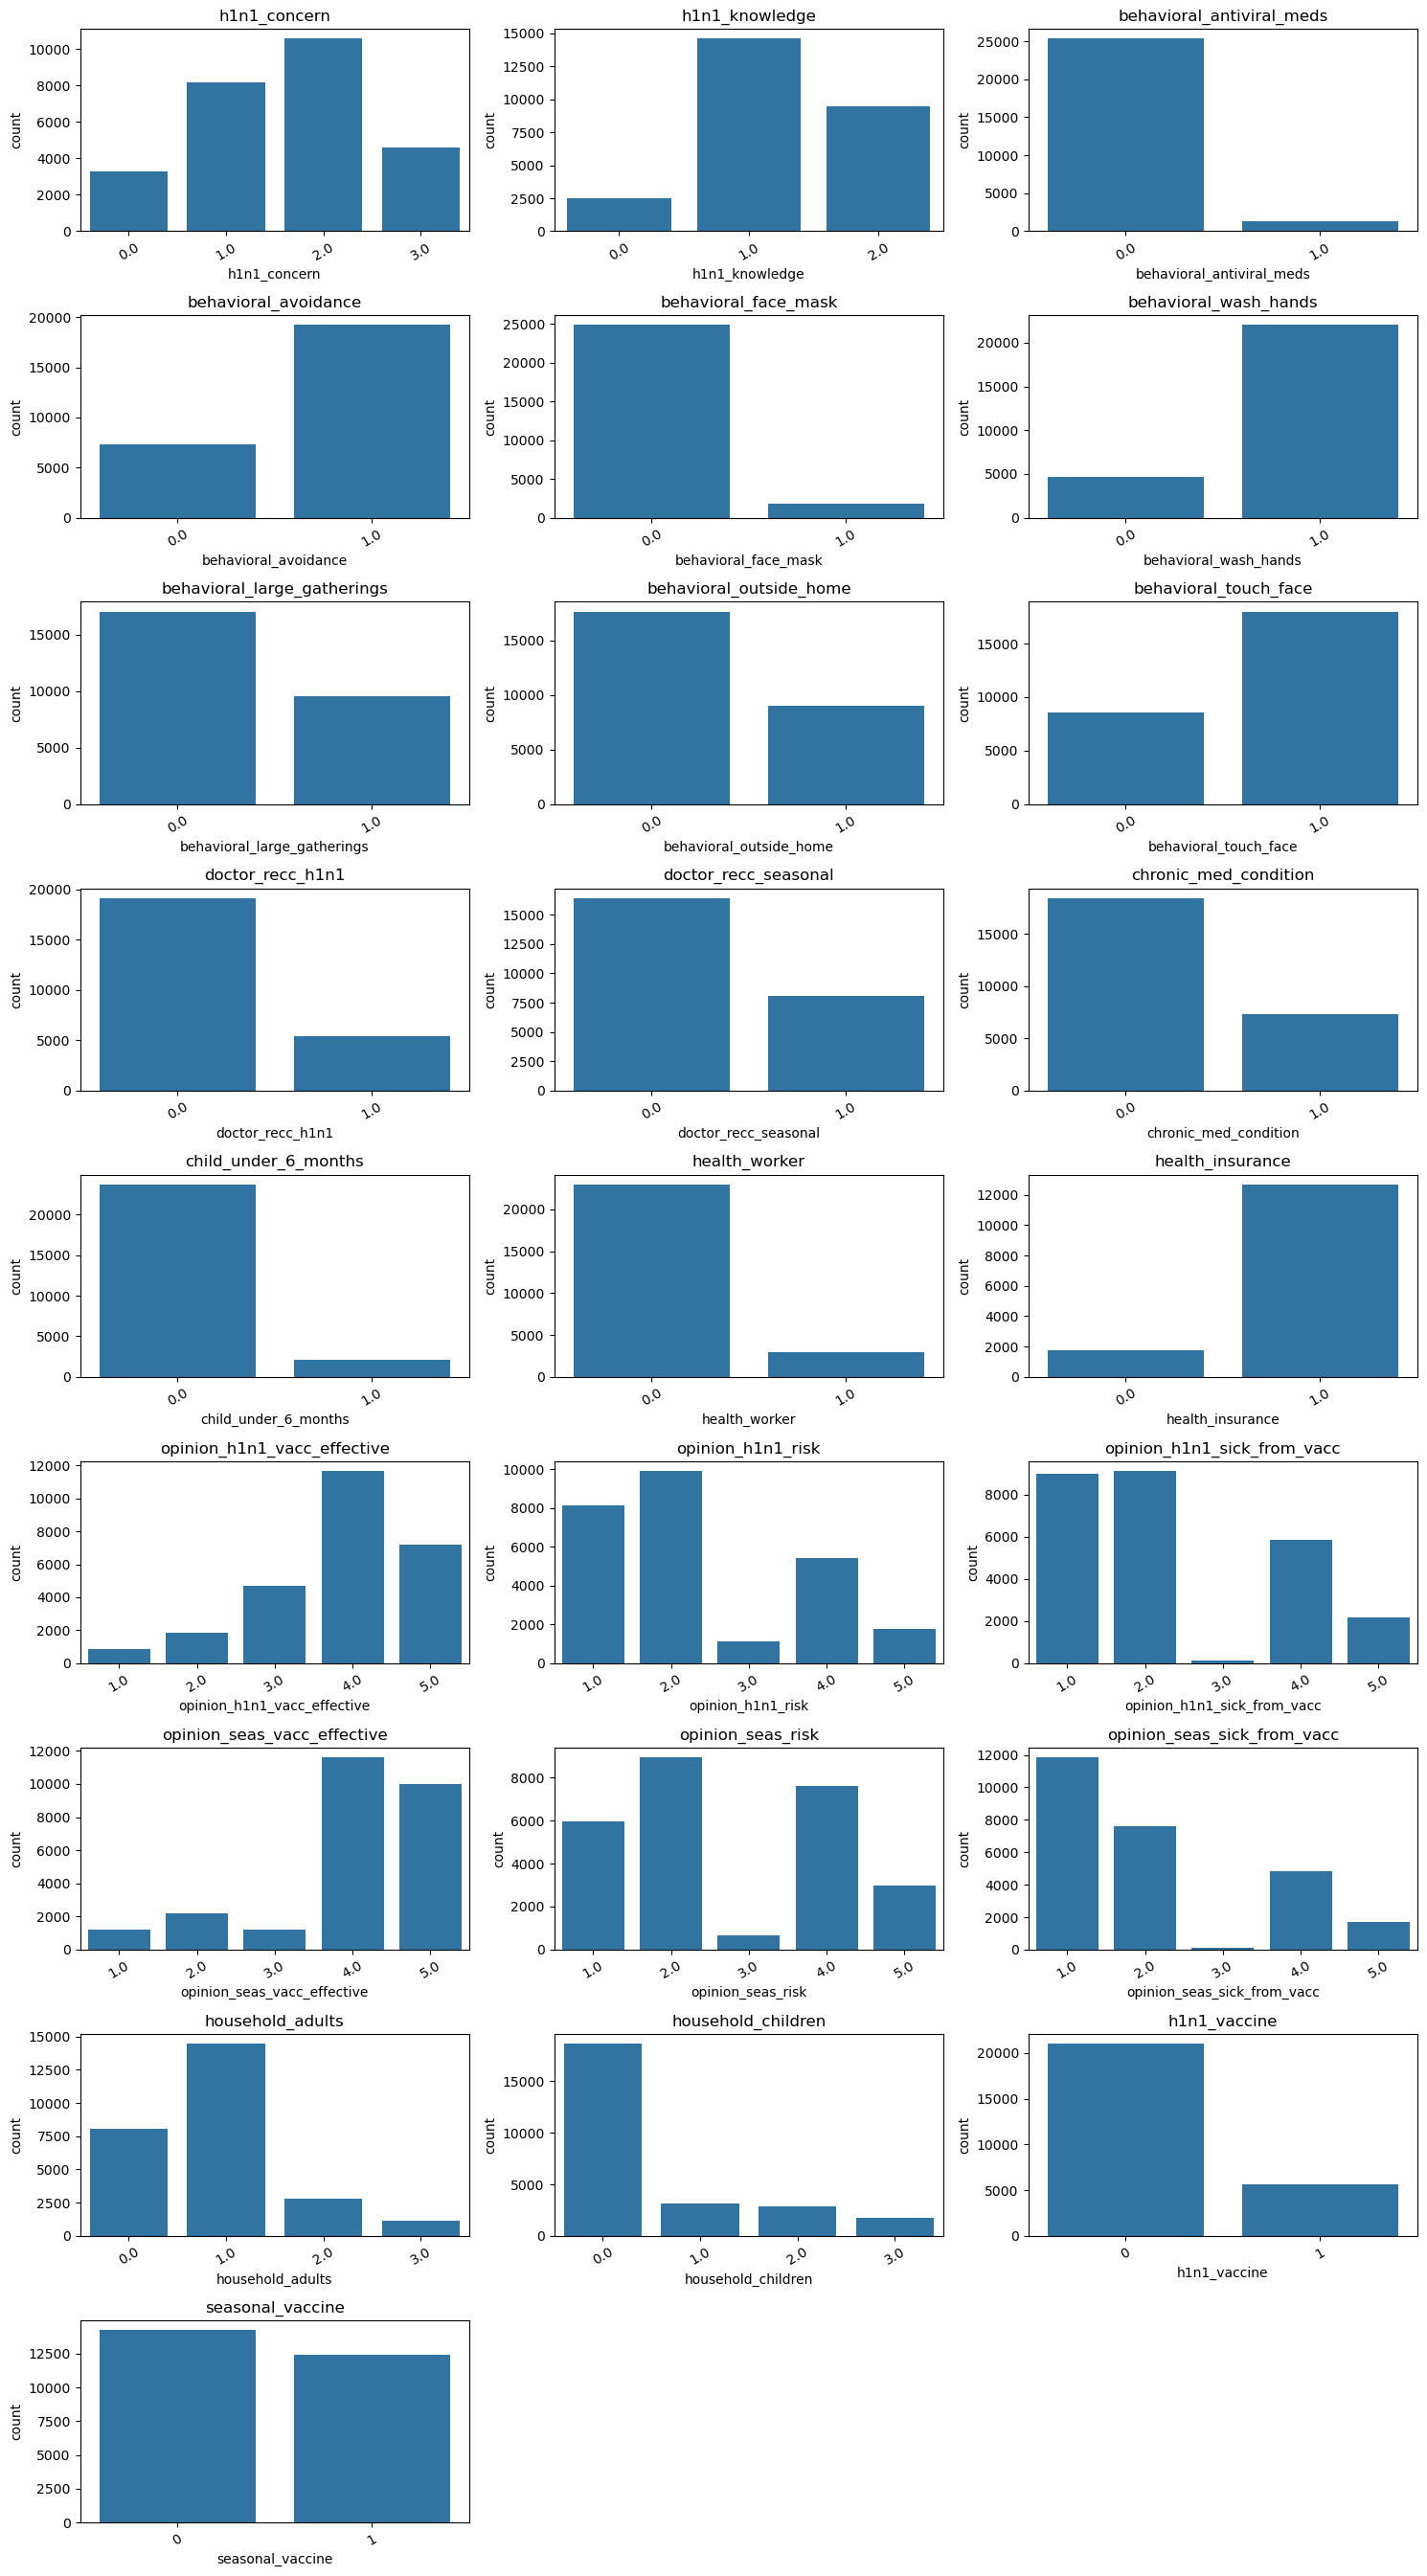

In [20]:
# Numerical Columns

# Countplot

cols = num_cols
n_cols = 3
n_rows = math.ceil(len(cols)/ n_cols) #ceil: ceiling = round up

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
axes = axes.flatten()  #flatten: convert from 2D to 1D

for i, col in enumerate(cols):
    order = sorted(data[col].dropna().unique()) #dropna: drop null values
    sns.countplot(x=data[col], order=order, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].tick_params(axis='x', rotation=30)
    
# To delete empty subplot    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])  #delaxes = delete axis: removes unused subplot from the grid.

plt.tight_layout()
plt.show()

##### Insights from Univariate analysis of Numerical features 
* Since most numerical features are either binary or nomial, count plots are used for univariate analysis in order to analyse through their frequency distribution.
* Features based on public opinion and doctor's recommendation forms the strong predictor as they directly influence the vaccination decision.
* Features related to behavioral and demographic variables are highly imbalanced thus can be considered as a weak predictor.
* Thus, on the basis of univariate analysis following will be features:
> * __strong features__: h1n1_concern, h1n1_knowledge, opinion_h1n1_vacc_effective, opinion_h1n1_risk, opinion_h1n1_sick_from_vacc, opinion_seas_vacc_effective, opinion_seas_risk, opinion_seas_sick_from_vacc, doctor_recc_h1n1, doctor_recc_seasonal
>* __weak features__: behavioral_antiviral_meds, behavioral_face_mask, behavioral_touch_face, child_under_6_months, health_worker, health_insurance, household_children, household_adults

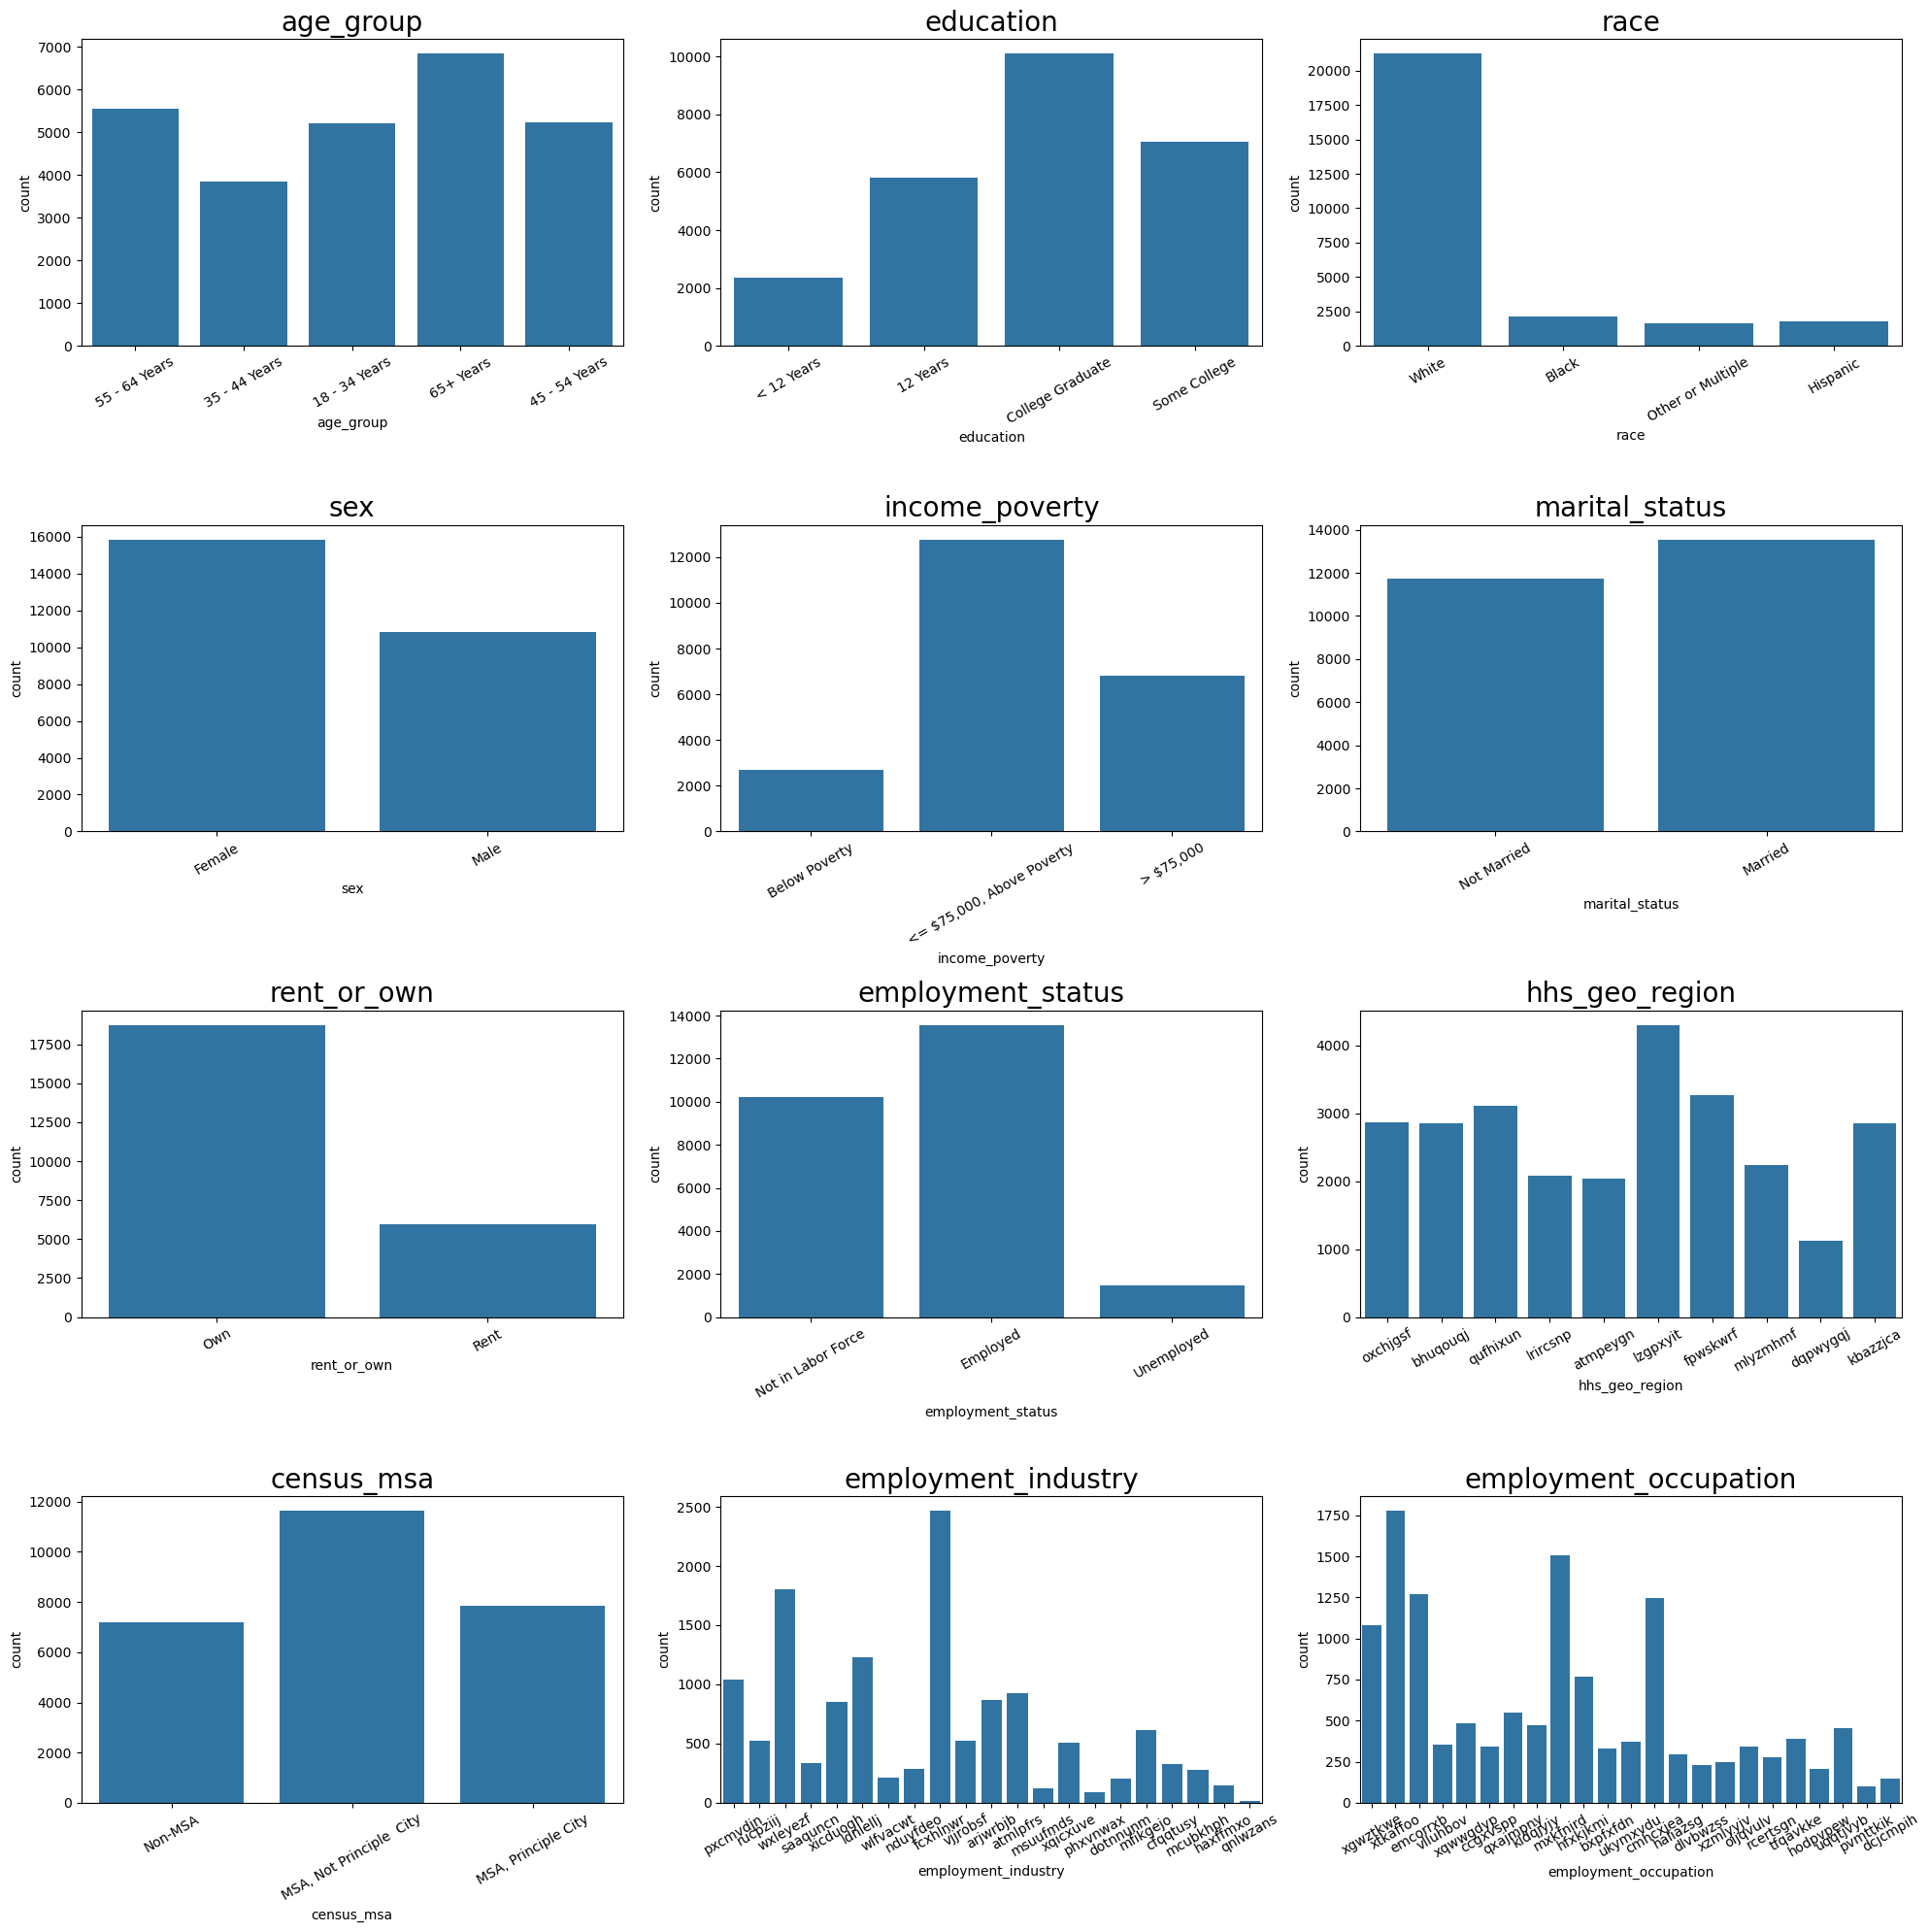

In [21]:
# Categorical Columns

#Countplot

n_cols = 3
n_rows = math.ceil(len(cat_cols)/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20,5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=data[col], ax=axes[i])
    axes[i].set_title(col,fontsize=20)
    axes[i].tick_params(axis='x', rotation=30)
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

#### Insights from Univariate analysis of Categorical features
* From above plot major variation with almost balanced distribution can be seen in age_group, education, sex, income_poverty, marital status, employment_status, HHS Geo Region, census MSA, employment industry, employment occupation.

<Axes: xlabel='age_group', ylabel='count'>

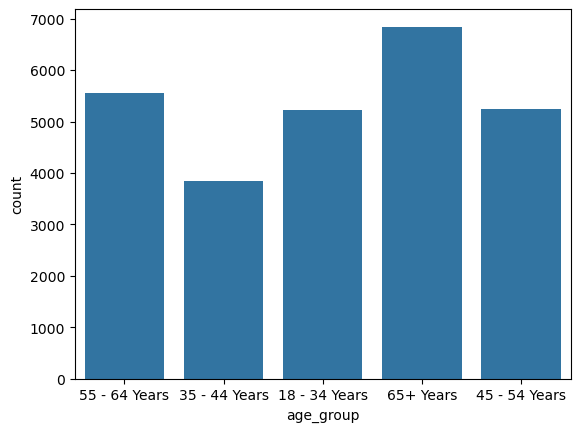

In [22]:
sns.countplot(x=data['age_group'])

* The distribution is fairly distributed showing more respondents in the 65+ years age.

<Axes: xlabel='education', ylabel='count'>

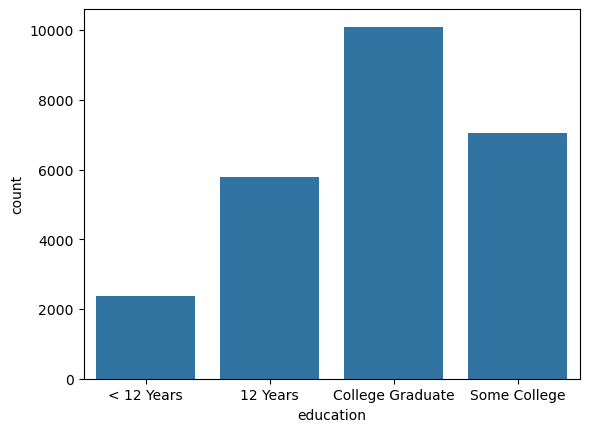

In [23]:
sns.countplot(x=data['education'])

* Count rate is high for college graduate and some college thereby showing more awareness regarding the vaccine in them.

<Axes: xlabel='employment_status', ylabel='count'>

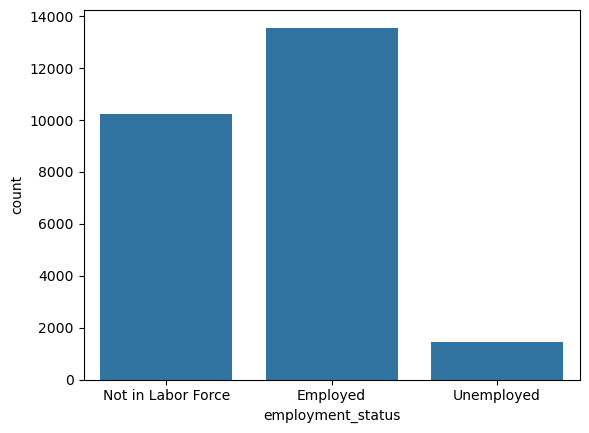

In [24]:
sns.countplot(x=data['employment_status'])

* The highest count is for employes and least for unemployed, thereby showing important demographic feature.

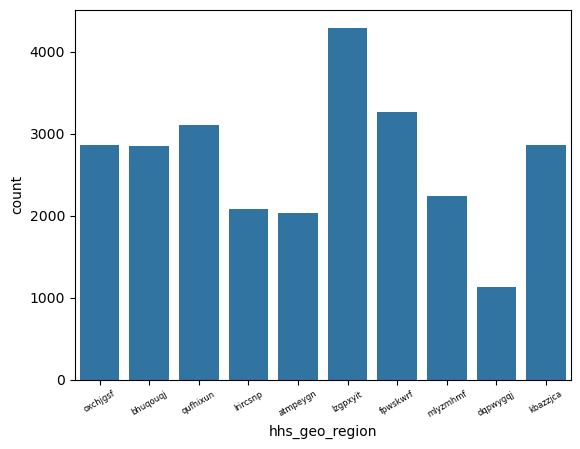

In [25]:
sns.countplot(x=data['hhs_geo_region'])
plt.xticks(rotation=30, fontsize= 6)
plt.show()

* The distribution has less amount of imbalance in it, thereby showing excellent variation.
* Thus this feature can be considered as a strong variable for predicting the vaccination intake.

* Thus following features can be considered as strong and weak respectively.
> * __strong features__: age group, education, sex, income poverty, marital status, rent or own, employment status, hhs geo region, census MSAemployment induatry and occupation
> * __weak features__: race

## Bivariate Analysis:

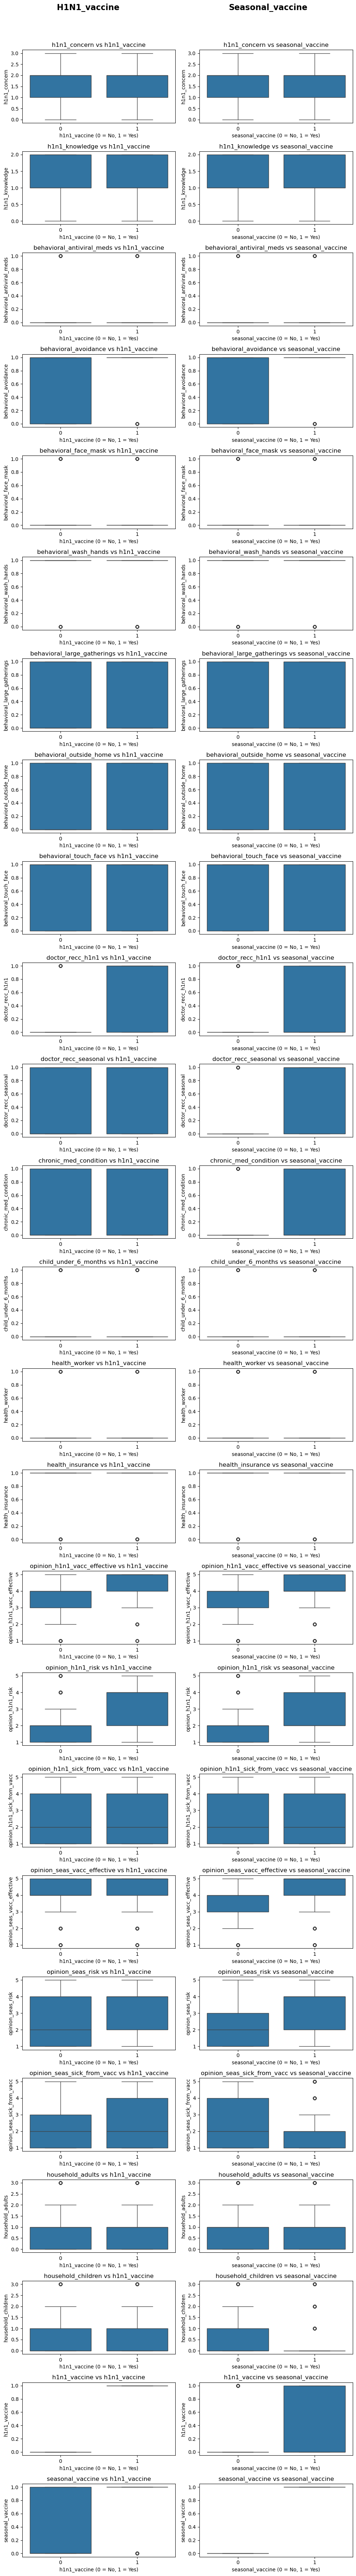

In [26]:
# Numerical vs target(categorical)

n_rows = len(num_cols)
n_cols = 2 # one for each target

fig, axes = plt.subplots(n_rows,n_cols, figsize=(10,3*n_rows))

# Column titles
fig.text(0.25, 0.95, "H1N1_vaccine", ha='center', fontsize=16, fontweight='bold')
fig.text(0.75, 0.95, 'Seasonal_vaccine', ha='center', fontsize=16, fontweight='bold')

for i, col in enumerate(num_cols):
    
    #Left Column = h1n1_vaccine
    # [i,0] : denote left plot for numeric feature i
    sns.boxplot(x=data['h1n1_vaccine'], y=data[col], ax=axes[i,0])
    axes[i,0].set_title(f'{col} vs h1n1_vaccine')
    axes[i,0].set_xlabel('h1n1_vaccine (0 = No, 1 = Yes)')
    axes[i,0].set_ylabel(col)
    
    
    #Right Column = Seasonal_vaccine
    # [i,1] : denote right plot for numeric feature i
    sns.boxplot(x=data['seasonal_vaccine'],y=data[col], ax=axes[i,1])
    axes[i,1].set_title(f'{col} vs seasonal_vaccine')
    axes[i,1].set_xlabel('seasonal_vaccine (0 = No, 1 = Yes)')
    axes[i,1].set_ylabel(col)
    
plt.tight_layout(rect=[0,0,1,0.94])
plt.show()

#### Insights from Bivariate Anlaysis for Numerical features:
* In the above plot the vaccinated and not vaccinated one is denoted by 1 and 0 respectively
* _Strong features_ : The medians for class 0 and 1 will be far apart, IQR (box region) will not overlap between the two classes, the shape of overall distribution will be different.
* _Moderate features_ : The medians will slightly differ and the box though seems similar but will still have some changes.
* _Weak features_ : The median will be same, box will fully overlap and there will be no visible shift.
* _Dropping features_ : the features that have no variation at all.

* On the basis of above points the features can be divided into following group for both the targets:
> * __strong features__ : doctor_recc_h1n1, doctor_recc_seasonal, opinion_h1n1_vacc_effective, opinion_h1n1_risk, opinion_seas_vacc_effective
> * __moderate features__ : opinion_seas_risk 
> * __weak features__ : h1n1_concern, h1n1_knowledge, opinion_h1n1_sick_from_vacc, opinion_seas_sick_from_vacc, household_children, household_adults.
> * __drop features__ : behavioral_antiviral_meds, behavioral_avoidance, behavioral_face_mask, behavioral_wash_hands, behavioral_large_gatherings, behavioral_outside_home, behavioral_touch_face, chronic_med_condition, child_under_6_months, health_worker, health_insurance. 


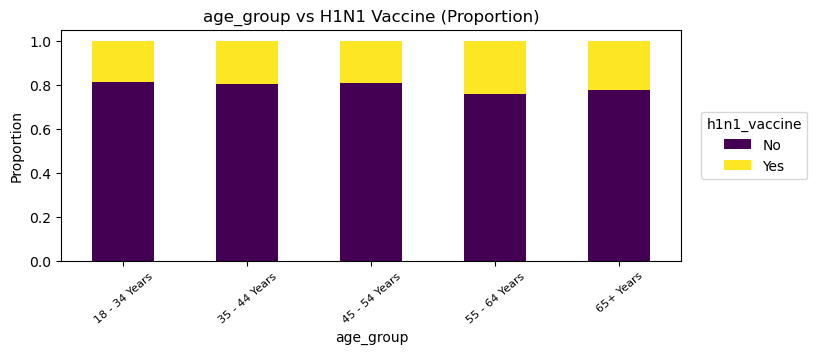

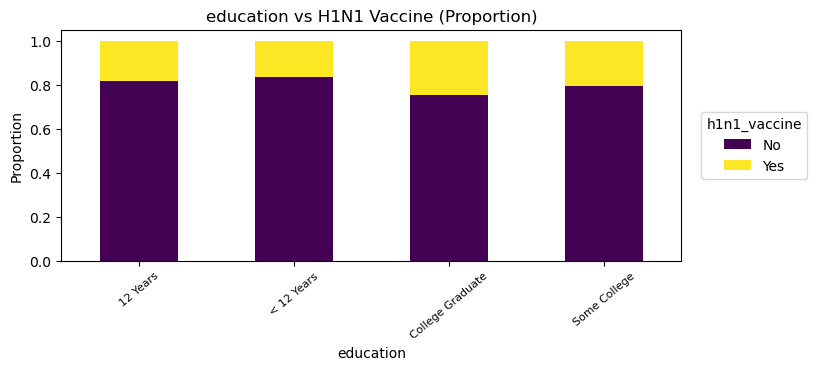

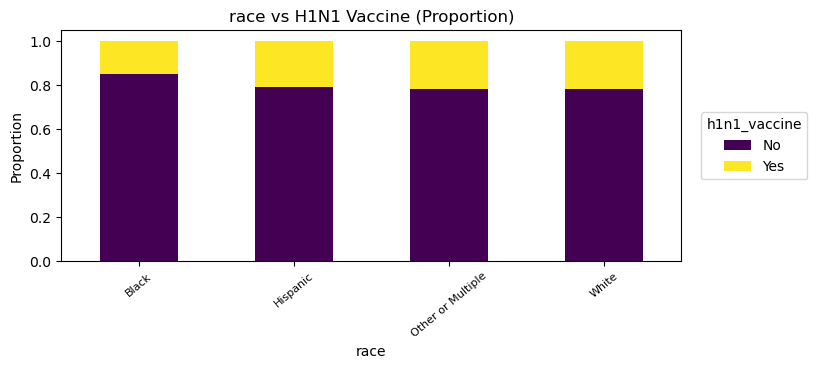

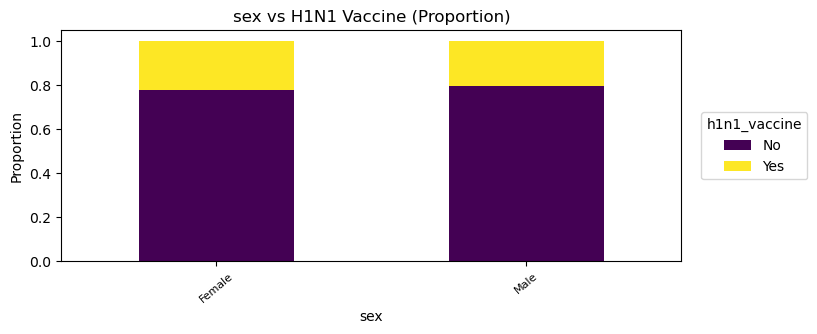

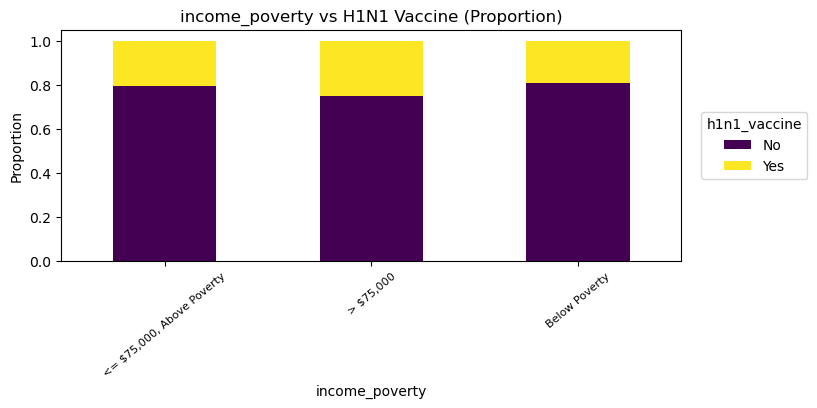

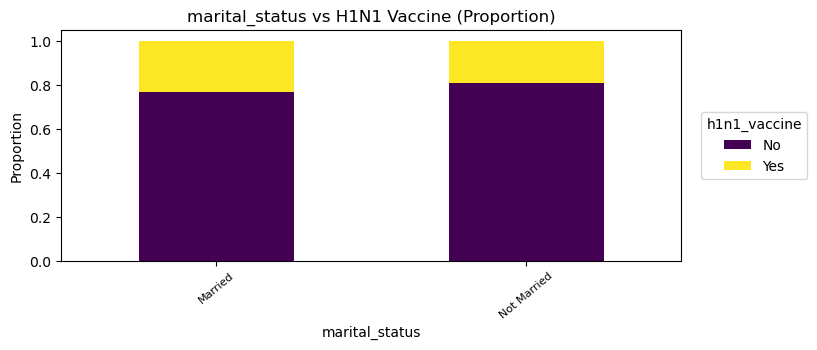

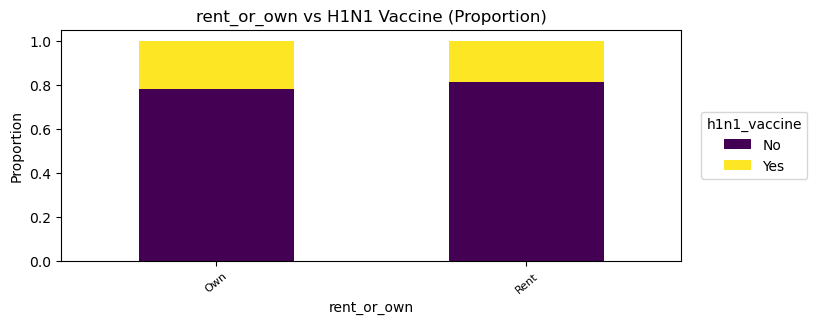

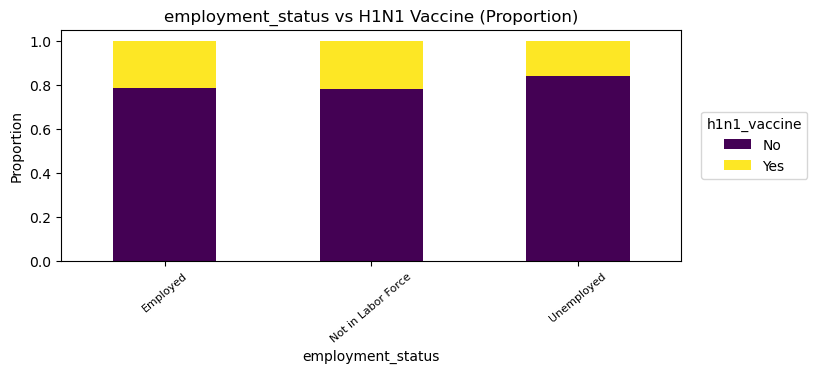

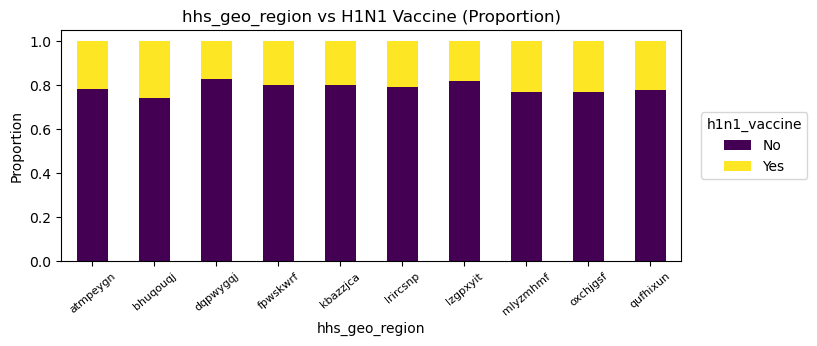

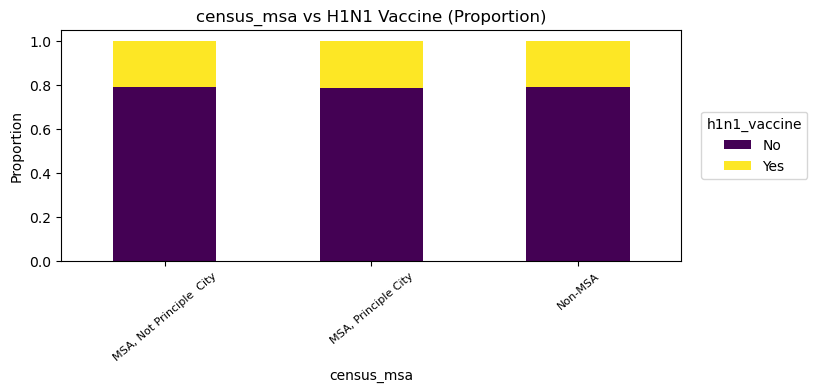

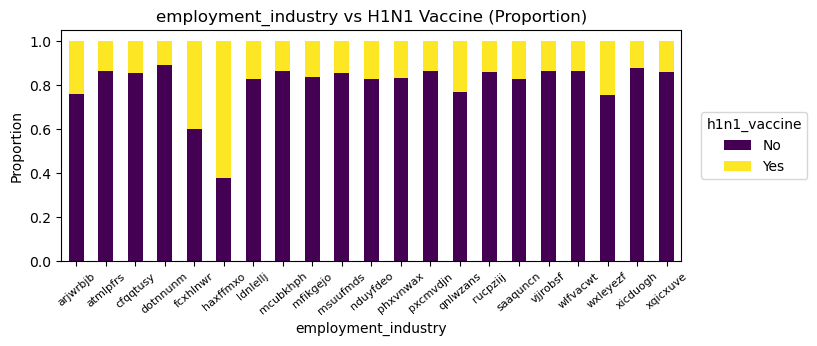

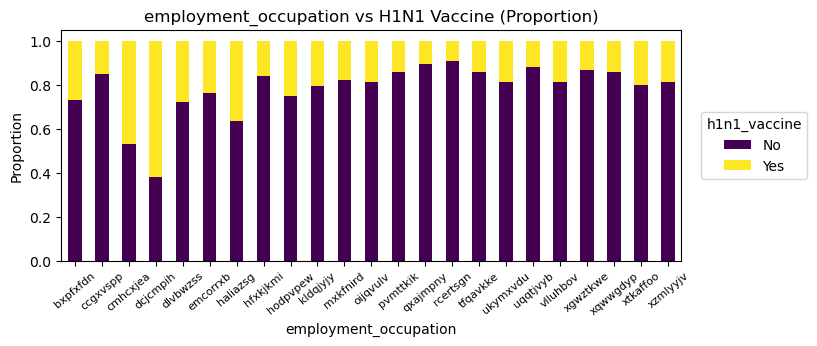

In [27]:
# Categorical vs target(Categorical)

# For H1N1_vaccine (Imbalanced dataset)
# Proportion Stacked Bar plot

for col in cat_cols:
    prop = pd.crosstab(data[col], data['h1n1_vaccine'], normalize='index')
    
    prop.plot(kind='bar', stacked=True,figsize=(8,3), colormap='viridis')
    plt.title(f'{col} vs H1N1 Vaccine (Proportion)')
    plt.ylabel("Proportion")
    plt.xticks(rotation=40, fontsize=8)
    
    
    
    plt.legend(['No','Yes'], 
               title='h1n1_vaccine',
              loc='center left',
              bbox_to_anchor=(1.02,0.5))  # tells location to to attach the legend at center left position.
    
    plt.show()

#### Insights from Bivariate analysis for H1N1 vaccine:
* The plot is normalized thus the height will always be 1 and the proportion will only be shown.
* _Strong predictors_: show big differences in proportions between the categories (in the ratio of 80:20) and bar looks very different.
* _Moderate predictors_: show not very large but noticeable trend.
* _Weak predictors_: show similar proportion acros different categories.
* Thus on the basis of these factors the variables can be divided as
> * __Strong features__: employment_industry, employment_occupation
> * __Moderate features__: education, income_poverty
> * __Weak features__: age_group, race, employment_status
> * __Dropping features__: sex, marital_status, rent_or_own, hhs_geo_region, census_msa

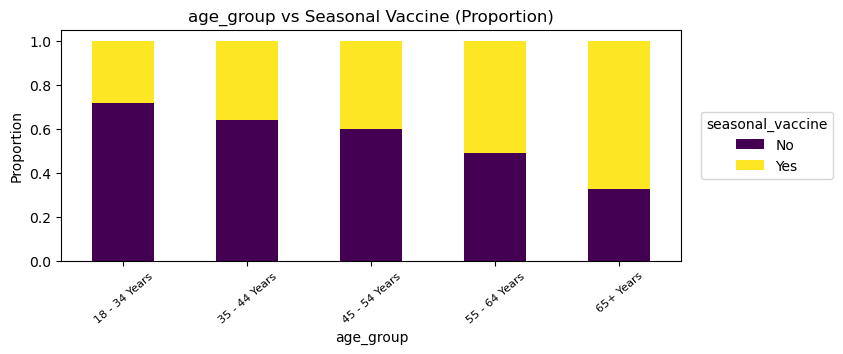

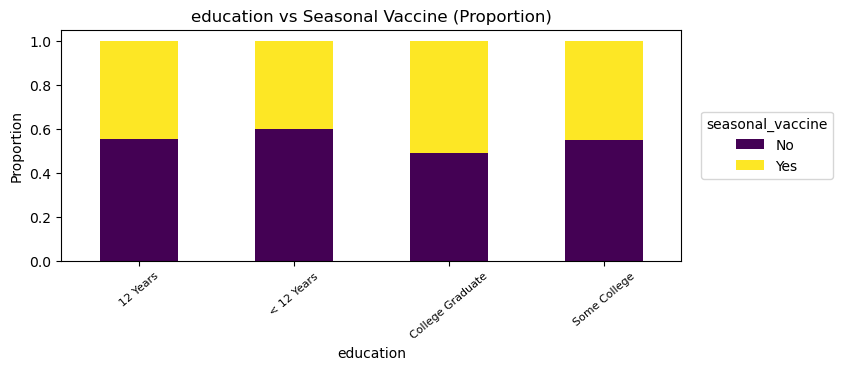

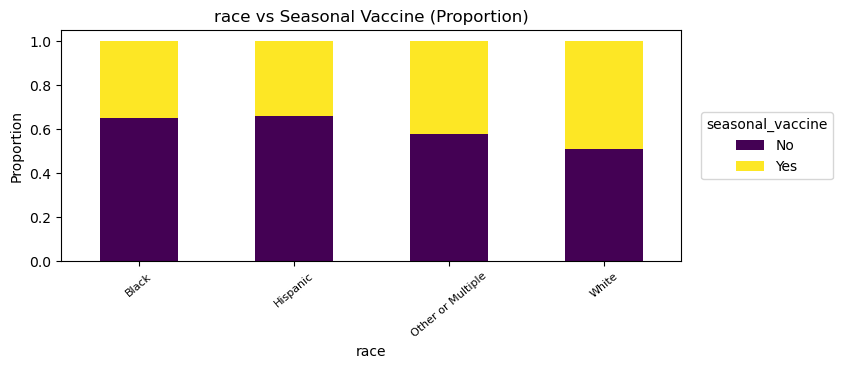

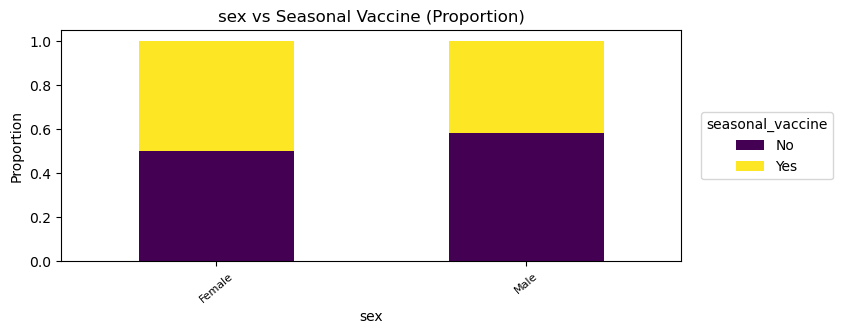

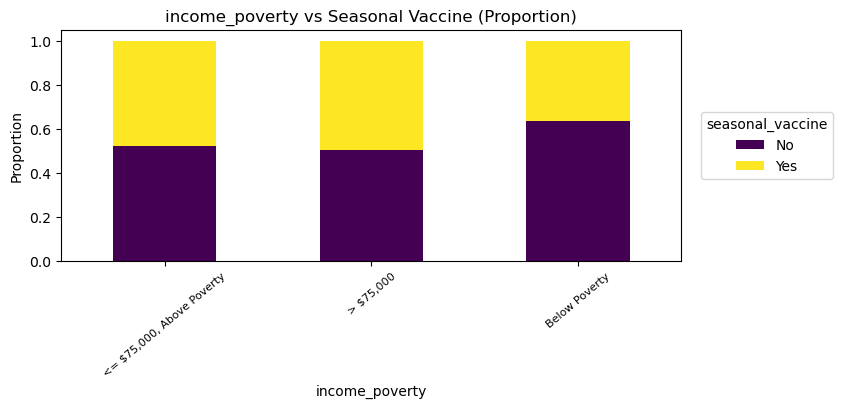

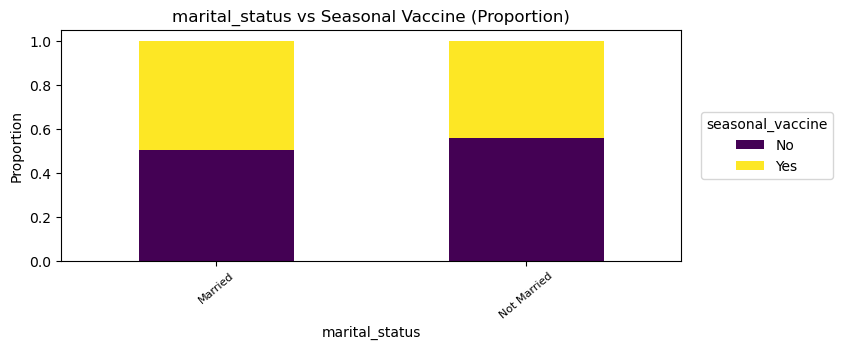

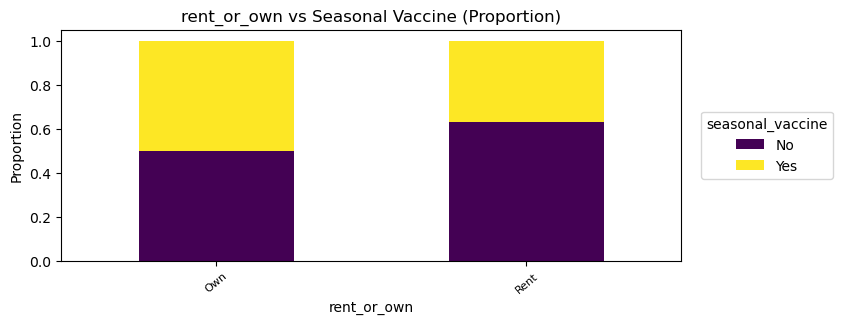

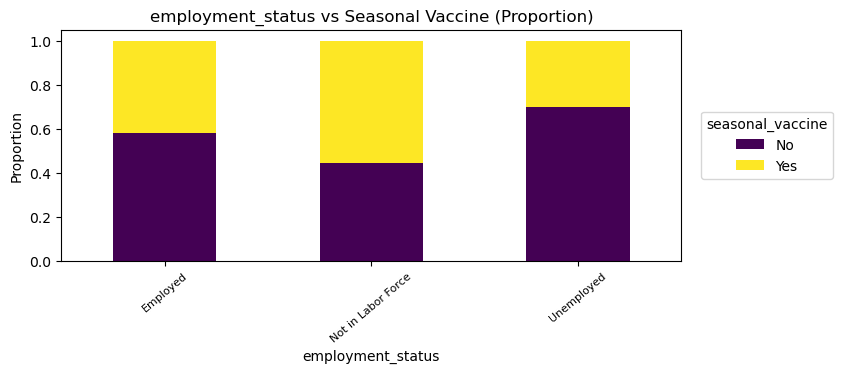

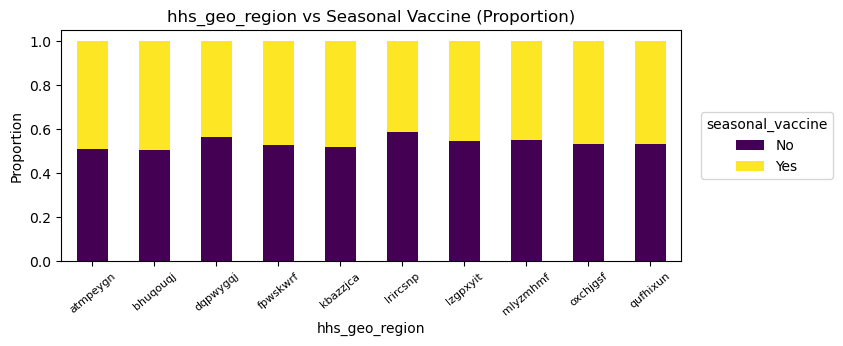

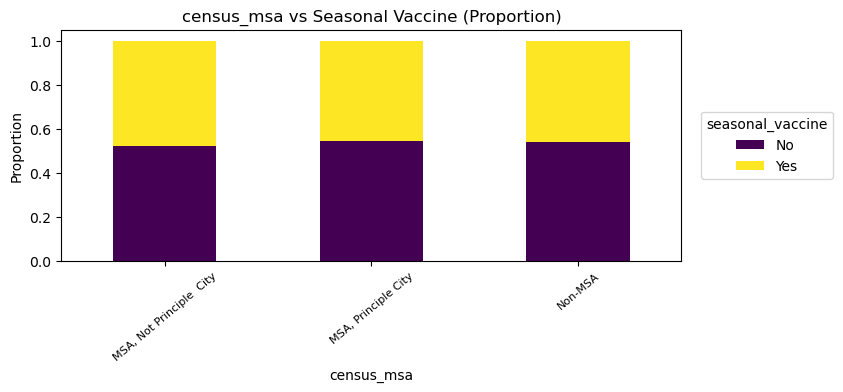

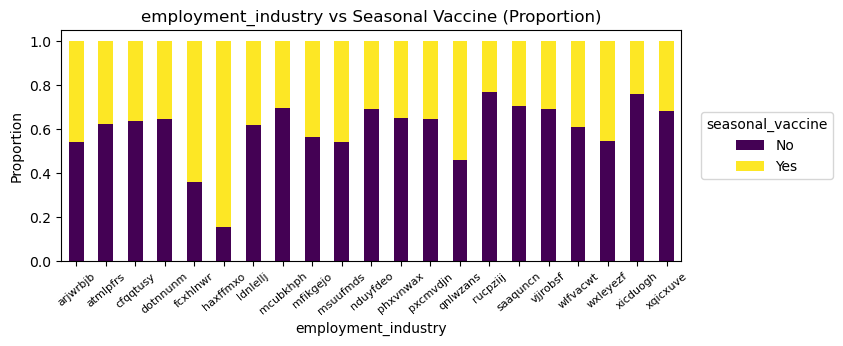

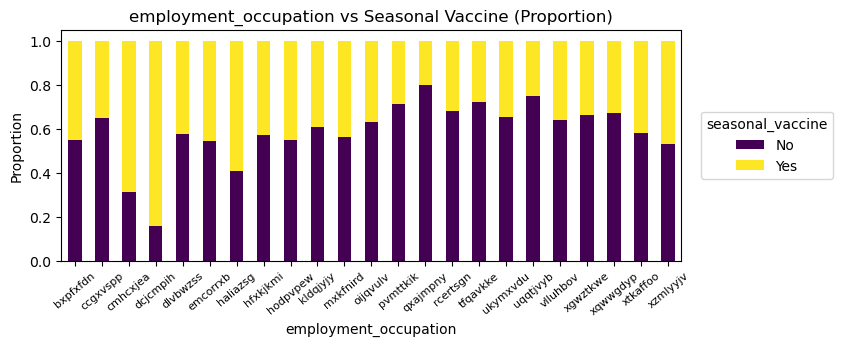

In [28]:
# For Seasonal_vacccine(balanced dataset)

#Proportion stacked Bar plot

for col in cat_cols:
    prop = pd.crosstab(data[col], data['seasonal_vaccine'], normalize='index')
    
    prop.plot(kind='bar', stacked=True,figsize=(8,3), colormap='viridis')
    plt.title(f'{col} vs Seasonal Vaccine (Proportion)')
    plt.ylabel("Proportion")
    plt.xticks(rotation=40, fontsize=8)
    plt.legend(['No','Yes'], title='seasonal_vaccine', loc='center left', bbox_to_anchor=(1.02,0.5))
    plt.show()

* Thus dataset being the balanced the proportions are more meaningful.
* Based on the plots the features can be categorized as:
> * __Strong features__: age_group, employment_status, employment_industry, employment_occupation
> * __Moderate features__: education, race, income_poverty
> * __Weak features__: sex, marital_status, rent_or_own
> * __Dropping features__: hhs_geo_region, census_msa

## Multivariate Analysis

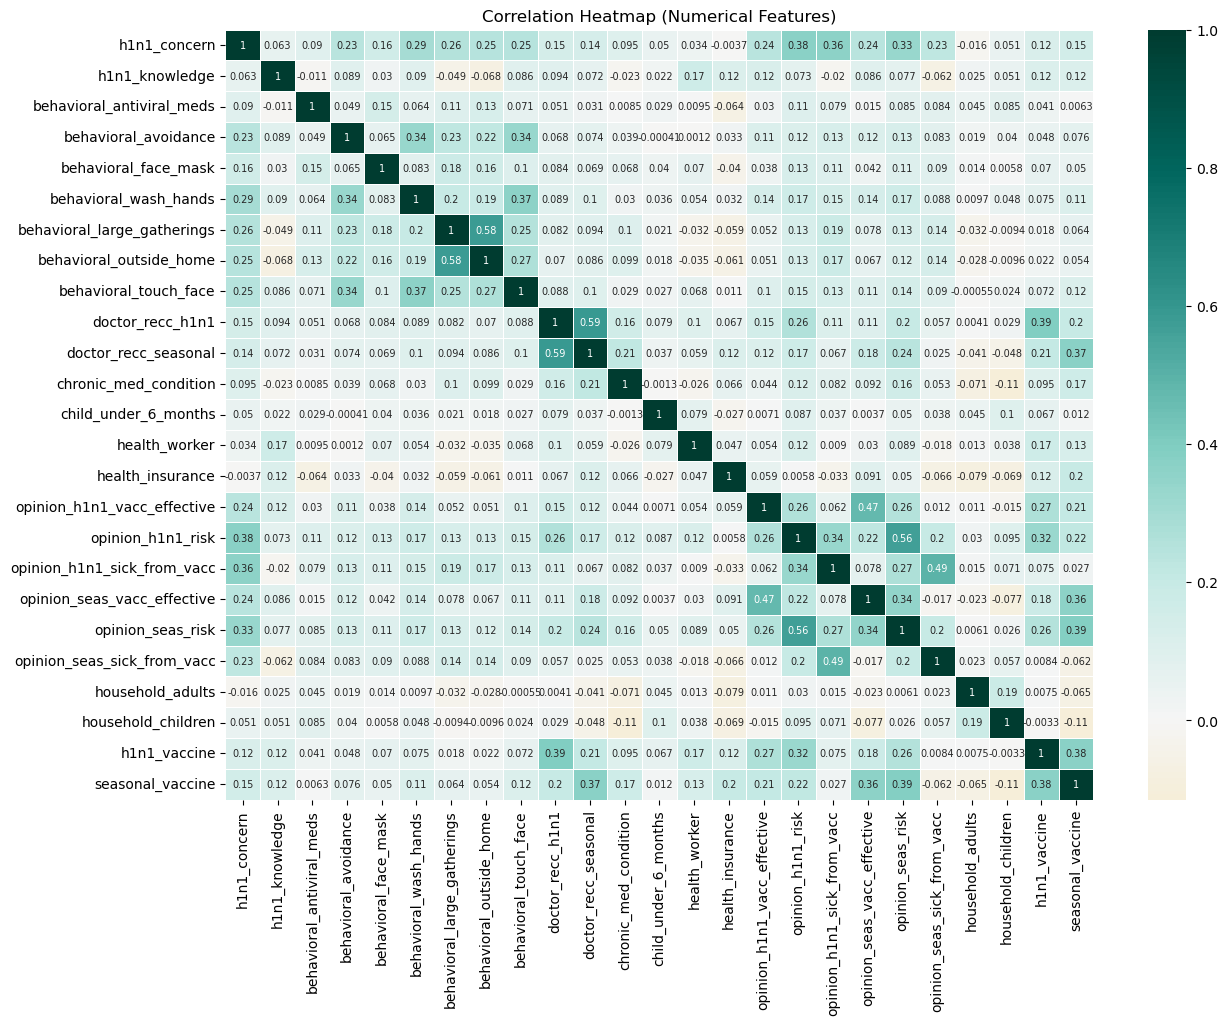

In [29]:
# Numerical vs numerical

# Pearson Correlation Heatmap

num_data = data[num_cols]  
corr_matrix = num_data.corr()  #to compute correlation matrix through Pearson correlation

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap = 'BrBG', center=0, linewidth=0.5, annot_kws={'size': 7})

plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

#### Insights from Multivariate analysis for Numerical features
* The heatmap revealed no severe multicollinearity among the numerical features.
* Opinion related variables exhibited moderate correlations, thereby reflecting consistent understandable patterns.
* Behavioral and demographic variables are showing weak correlations thereby indicating independence.
* For now no numerical features are removed solely on the basis of multicollinearity.

 ##### Dropping unnecessary  features

* Based on EDA, features exhibiting minimal variance or negligible association with prediction of vaccination outcomes are removed before the preprocessing.
* The removal is done to reduce noise and improve model generalization.

In [30]:
data = data.drop(columns=[ 'respondent_id',
    'household_adults',
    'household_children',
    'child_under_6_months',
    'health_worker',
    'health_insurance',
    'behavioral_avoidance',
    'behavioral_face_mask',
    'behavioral_large_gatherings',
    'behavioral_wash_hands'])

# Data Preprocessing:

In [31]:
# Numerical Features
data

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,NaN,NaN,0,0
1,3.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",pxcmvdjn,xgwztkwe,0,1
2,1.0,1.0,0.0,0.0,0.0,NaN,NaN,1.0,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",rucpziij,xtkaffoo,0,0
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",NaN,NaN,0,1
4,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",wxleyezf,emcorrxb,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0,5.0,2.0,2.0,65+ Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,qufhixun,Non-MSA,NaN,NaN,0,0
26703,1.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,4.0,2.0,2.0,5.0,1.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,lzgpxyit,"MSA, Principle City",fcxhlnwr,cmhcxjea,0,0
26704,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,4.0,2.0,5.0,4.0,2.0,55 - 64 Years,Some College,White,Female,NaN,Not Married,Own,NaN,lzgpxyit,"MSA, Not Principle City",NaN,NaN,0,1
26705,1.0,1.0,0.0,0.0,NaN,0.0,0.0,0.0,3.0,1.0,2.0,2.0,1.0,2.0,18 - 34 Years,Some College,Hispanic,Female,"<= $75,000, Above Poverty",Married,Rent,Employed,lrircsnp,Non-MSA,fcxhlnwr,haliazsg,0,0


In [32]:
#Target variables
target_cols = ['h1n1_vaccine', 'seasonal_vaccine']

In [33]:
# Defining the features
X = data.drop(columns=target_cols)  #input features
y = data[target_cols]    #target feature

In [34]:
# Train-test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)  #stratify = maintains same class proportion in both training and testing set 

In [35]:
#Identify numerical and categorical columns from the train data
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns
print('Numerical columns:',num_cols)
print('Categorical columns:',cat_cols)

Numerical columns: Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1',
       'doctor_recc_seasonal', 'chronic_med_condition',
       'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc'],
      dtype='object')
Categorical columns: Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry', 'employment_occupation'],
      dtype='object')


##### Handling missing values:

In [36]:
X_train.isnull().sum()

h1n1_concern                      73
h1n1_knowledge                    90
behavioral_antiviral_meds         57
behavioral_outside_home           65
behavioral_touch_face             96
doctor_recc_h1n1                1718
doctor_recc_seasonal            1718
chronic_med_condition            768
opinion_h1n1_vacc_effective      326
opinion_h1n1_risk                316
opinion_h1n1_sick_from_vacc      323
opinion_seas_vacc_effective      372
opinion_seas_risk                418
opinion_seas_sick_from_vacc      432
age_group                          0
education                       1127
race                               0
sex                                0
income_poverty                  3530
marital_status                  1122
rent_or_own                     1619
employment_status               1172
hhs_geo_region                     0
census_msa                         0
employment_industry            10607
employment_occupation          10716
dtype: int64

In [37]:
X_train[num_cols].isnull().sum()

h1n1_concern                     73
h1n1_knowledge                   90
behavioral_antiviral_meds        57
behavioral_outside_home          65
behavioral_touch_face            96
doctor_recc_h1n1               1718
doctor_recc_seasonal           1718
chronic_med_condition           768
opinion_h1n1_vacc_effective     326
opinion_h1n1_risk               316
opinion_h1n1_sick_from_vacc     323
opinion_seas_vacc_effective     372
opinion_seas_risk               418
opinion_seas_sick_from_vacc     432
dtype: int64

In [38]:
X_train[cat_cols].isnull().sum()

age_group                    0
education                 1127
race                         0
sex                          0
income_poverty            3530
marital_status            1122
rent_or_own               1619
employment_status         1172
hhs_geo_region               0
census_msa                   0
employment_industry      10607
employment_occupation    10716
dtype: int64


* Missing values are handled using a preprocessing pipeline in which numerical features are imputed by median and categorical features by mode to ensure scalability and prevent data leakage.

In [39]:
# Numerical and Categorical imputation

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_imputer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
cat_imputer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent'))])

In [40]:
# Combining the imputers using ColumnTransformer

from sklearn.compose import ColumnTransformer

imputer = ColumnTransformer(transformers=[
    ('num', num_imputer, num_cols),
    ('cat',cat_imputer, cat_cols)
])

In [41]:
# Applying imputation
X_train_imputed = imputer.fit_transform(X_train)  #fit_transform: learn the parameters and then apply it on data
X_test_imputed = imputer.transform(X_test)     #transform: apply it on data

##### Handling Outliers and Skewness
* In this particular dataset most features are discrete and no continuous numerical column exist.
* So removal of outlier and skewness will not improve the model but would rather distort the catergory distribution.
* Therefore the outlier and skewness detection part can be skipped in this dataset.

##### Scaling (to numerical) and Encoding (to categorical)

In [42]:
# Adding scaling to numerical pipeline
# (imputation + scaling)

from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [43]:
# Adding encoding to categorical pipeline
# (imputation + encoding)

from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))  
])
# (drop = first): remove one dummy column to avoid redundancy
# (handle_unknown = ignore): to ensure the model for unseen categories during testing.

* One Hot Encoder is used by default as it makes no assumption about category order, whereas Ordinal encoding should only be applied when a true and meaningful order exists.

In [44]:
# Combining pipelines (num + cat) using ColumnTransformer
preprocessor = ColumnTransformer(
transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [45]:
# Transformed data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(X_train_processed.shape)
print(X_test_processed.shape)

(21365, 84)
(5342, 84)


# Model Building & Evaluation:

### Logistic Regression

In [46]:
# Step 1 : Import the required libraries

from sklearn.linear_model import LogisticRegression

In [47]:
# Step 2: Building the model pipelines

# H1N1 Vaccine Model(Imbalanced)


h1n1_model = Pipeline(steps=[
    ('preprocessor', preprocessor), #applies (numerical imputation + scaling) and (categorical + encoding)
    ('model', LogisticRegression(
    max_iter = 1000,  # no of chances to correct mistake
    class_weight = 'balanced',   # to balance the imbalanced dataset
    random_state = 42))  # ensures reproducibility
    
])



# Seasonal Vaccine Model(Balanced)

seasonal_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
    max_iter = 1000,
    random_state = 42))
])

In [48]:
# Step 3 : Training (fit) the models

h1n1_model.fit(X_train, y_train['h1n1_vaccine'])
seasonal_model.fit(X_train, y_train['seasonal_vaccine'])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1',
       'doctor_recc_seasonal', 'chronic_med_condition',
       'opin...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry', 'employment_occupation'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [49]:
# Step 4 : Predictions (Train & Test)

# H1N1
y_train_pred_h1n1_lr = h1n1_model.predict(X_train)
y_test_pred_h1n1_lr = h1n1_model.predict(X_test)

# Seasonal
y_train_pred_seasonal_lr = seasonal_model.predict(X_train)
y_test_pred_seasonal_lr = seasonal_model.predict(X_test)

#### Evaluation

##### H1N1 vaccine



* As h1n1 vaccine has __imbalanced__ dataset therefore the priority order for better model should be : 
> * recall 
> * F1 score
> * precision 
> * accuracy

In [50]:
# Step 5 : Evaluate performance
# Train Performance


from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix)

print("H1N1 - Logistic Regression Train Performance")
print("Train accuracy:", accuracy_score(y_train['h1n1_vaccine'], y_train_pred_h1n1_lr))
print(confusion_matrix(y_train['h1n1_vaccine'], y_train_pred_h1n1_lr))
print(classification_report(y_train['h1n1_vaccine'], y_train_pred_h1n1_lr))


# Test Performance

print("\nH1N1 -  Logistic Regression Test Performance")
print("Test accuracy:", accuracy_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_lr))
print(confusion_matrix(y_test['h1n1_vaccine'], y_test_pred_h1n1_lr))
print(classification_report(y_test['h1n1_vaccine'], y_test_pred_h1n1_lr))

H1N1 - Logistic Regression Train Performance
Train accuracy: 0.7775333489351743
[[13286  3540]
 [ 1213  3326]]
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     16826
           1       0.48      0.73      0.58      4539

    accuracy                           0.78     21365
   macro avg       0.70      0.76      0.72     21365
weighted avg       0.82      0.78      0.79     21365


H1N1 -  Logistic Regression Test Performance
Test accuracy: 0.7789217521527517
[[3327  880]
 [ 301  834]]
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      4207
           1       0.49      0.73      0.59      1135

    accuracy                           0.78      5342
   macro avg       0.70      0.76      0.72      5342
weighted avg       0.83      0.78      0.79      5342



#### Insights of h1n1 vaccine from Logistic Regression
* The logistic Regression model for H1N1 vaccine prediction gains stable performance with approximately __78% accuracy__ on both the training and testing datasets.
* Thus shows good generalization thereby effectively prioritizing recall for the vaccinated class in the imbalanced dataset.

##### Seasonal  vaccine

* As seasonal vaccine has __balanced__ dataset therefore the priority order for better model should be : 
> * accuracy
> * F1 score
> * precision
> * recall

In [51]:
# Train Performance

print("\nSeasonal -  Logistic Regression Train Performance")
print("Train accuracy:", accuracy_score(y_train['seasonal_vaccine'], y_train_pred_seasonal_lr))
print(confusion_matrix(y_train['seasonal_vaccine'], y_train_pred_seasonal_lr))
print(classification_report(y_train['seasonal_vaccine'], y_train_pred_seasonal_lr))


# Test Performance

print("\nSeasonal -  Logistic Regression Test Performance")
print("Test accuracy:", accuracy_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_lr))
print(confusion_matrix(y_test['seasonal_vaccine'], y_test_pred_seasonal_lr))
print(classification_report(y_test['seasonal_vaccine'], y_test_pred_seasonal_lr))


Seasonal -  Logistic Regression Train Performance
Train accuracy: 0.7819798736250878
[[9292 2126]
 [2532 7415]]
              precision    recall  f1-score   support

           0       0.79      0.81      0.80     11418
           1       0.78      0.75      0.76      9947

    accuracy                           0.78     21365
   macro avg       0.78      0.78      0.78     21365
weighted avg       0.78      0.78      0.78     21365


Seasonal -  Logistic Regression Test Performance
Test accuracy: 0.7822912766754024
[[2322  532]
 [ 631 1857]]
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      2854
           1       0.78      0.75      0.76      2488

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



#### Insights of seasonal vaccine from Logistic Regression
* The Seasonal vaccone prediction model demonstrates stable and well balanced performance with around __78% accuracy__ on both training and testing datasets.
* The result indicates good generalization and reliable identification of both vaccination and non vaccinated individuals.

### Random Forest Classifier

In [52]:
# Step 1 : Import the required libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Step 2 : Building the model pipeline

# H1N1_vaccine

rf_h1n1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
    n_estimators=300,  # build 300 decision trees 
    max_depth=15,      # each tree can grow up to 15 levels deep to prevent overfitting
    class_weight='balanced',
    random_state=42))
])

# Seasonal_vaccine

rf_seasonal = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
    n_estimators=300,  
    max_depth=15,      
    random_state=42))
])


In [53]:
# Step 3 : Training the model
rf_h1n1.fit(X_train, y_train['h1n1_vaccine'])
rf_seasonal.fit(X_train, y_train['seasonal_vaccine'])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1',
       'doctor_recc_seasonal', 'chronic_med_condition',
       'opin...
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry', 'employment_occupation'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(max_depth=15, n_estimators=300,
                                        random_state=42))])

In [54]:
# Step 4 : Predict (train & test)

# H1N1_vaccine
y_train_pred_h1n1_rf = rf_h1n1.predict(X_train)
y_test_pred_h1n1_rf = rf_h1n1.predict(X_test)

# Seasonal_vaccine
y_train_pred_seasonal_rf = rf_seasonal.predict(X_train)
y_test_pred_seasonal_rf = rf_seasonal.predict(X_test)

#####  Evaluation

In [55]:
# Step 5 : Evaluate performance
# H1N1 vaccine
print("H1N1 -  Random Forest Classifier Train Performance")
print("Train accuracy:", accuracy_score(y_train['h1n1_vaccine'], y_train_pred_h1n1_rf))
print(confusion_matrix(y_train['h1n1_vaccine'], y_train_pred_h1n1_rf))
print(classification_report(y_train['h1n1_vaccine'], y_train_pred_h1n1_rf))

print("\nH1N1 - Random Forest Classifier Test Performance")
print("Test accuracy:", accuracy_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_rf))
print(confusion_matrix(y_test['h1n1_vaccine'], y_test_pred_h1n1_rf))
print(classification_report(y_test['h1n1_vaccine'], y_test_pred_h1n1_rf))



H1N1 -  Random Forest Classifier Train Performance
Train accuracy: 0.9225368593494032
[[15902   924]
 [  731  3808]]
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     16826
           1       0.80      0.84      0.82      4539

    accuracy                           0.92     21365
   macro avg       0.88      0.89      0.89     21365
weighted avg       0.92      0.92      0.92     21365


H1N1 - Random Forest Classifier Test Performance
Test accuracy: 0.824971920628978
[[3758  449]
 [ 486  649]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      4207
           1       0.59      0.57      0.58      1135

    accuracy                           0.82      5342
   macro avg       0.74      0.73      0.74      5342
weighted avg       0.82      0.82      0.82      5342



#### Insights of h1n1 vaccine from Random Forest Classifier
* The Random Forest model improves the H1N1 vaccine prediction accuracy to over __82%__ on unseen data, thereby showing strong performance for non- vaccinated individuals and moderate recall for vaccinated individuals with mild overfitting.

In [56]:
# Seasonal vaccine
print("\nSeasonal - Random Forest Classifier Train Performance")
print("Train accuracy:", accuracy_score(y_train['seasonal_vaccine'], y_train_pred_seasonal_rf))
print(confusion_matrix(y_train['seasonal_vaccine'], y_train_pred_seasonal_rf))
print(classification_report(y_train['seasonal_vaccine'], y_train_pred_seasonal_rf))

print("\nSeasonal - Random Forest Classifier Test Performance")
print("Test accuracy:", accuracy_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_rf))
print(confusion_matrix(y_test['seasonal_vaccine'], y_test_pred_seasonal_rf))
print(classification_report(y_test['seasonal_vaccine'], y_test_pred_seasonal_rf))


Seasonal - Random Forest Classifier Train Performance
Train accuracy: 0.9087292300491459
[[10660   758]
 [ 1192  8755]]
              precision    recall  f1-score   support

           0       0.90      0.93      0.92     11418
           1       0.92      0.88      0.90      9947

    accuracy                           0.91     21365
   macro avg       0.91      0.91      0.91     21365
weighted avg       0.91      0.91      0.91     21365


Seasonal - Random Forest Classifier Test Performance
Test accuracy: 0.7753650318232872
[[2303  551]
 [ 649 1839]]
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      2854
           1       0.77      0.74      0.75      2488

    accuracy                           0.78      5342
   macro avg       0.77      0.77      0.77      5342
weighted avg       0.78      0.78      0.78      5342



#### Insights of seasonal vaccine from Random Forest Classifier
* The Random Forest Classifier achieves strong. reliable and balanced performance for seasonal vaccine prediction with a __test accuracy__ of around __78%__, showing strong recall and F1 scores for both the classes.
* Also moderate overfitting is observed due to high training accuracy.

### Gradient Boosting Classifier

In [57]:
# Step 1 : Import the required libraries
from sklearn.ensemble import GradientBoostingClassifier

In [58]:
# Step 2 : Building the model pipelines

# H1N1 vaccine (Imbalanced)

h1n1_gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
    n_estimators = 100,   #number of decision trees
    learning_rate = 0.1,  #strength of each tree to correct the mistake
    max_depth = 3,        # complexicity of each tree
    random_state=42))
])

seasonal_gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
        max_depth=3,
    random_state=42))
])

In [59]:
# Step 3 : Train(fit) the models
h1n1_gb_model.fit(X_train, y_train['h1n1_vaccine'])
seasonal_gb_model.fit(X_train, y_train['seasonal_vaccine'])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1',
       'doctor_recc_seasonal', 'chronic_med_condition',
       'opin...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa', 'employment_industry', 'employment_occupation'],
      dtype='object'))])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [60]:
# Step 4 : Predictions (train & test)

# H1N1 vaccine
y_train_pred_h1n1_gb = h1n1_gb_model.predict(X_train)
y_test_pred_h1n1_gb = h1n1_gb_model.predict(X_test)

# Seasonal vaccine
y_train_pred_seasonal_gb = seasonal_gb_model.predict(X_train)
y_test_pred_seasonal_gb = seasonal_gb_model.predict(X_test)

In [61]:
# Step 5 : Evaluate performance

# H1N1 vaccine
print("H1N1 - Gradient Boosting Train Performance")
print("Accuracy:", accuracy_score(y_train['h1n1_vaccine'], y_train_pred_h1n1_gb))
print(confusion_matrix(y_train['h1n1_vaccine'], y_train_pred_h1n1_gb))
print(classification_report(y_train['h1n1_vaccine'], y_train_pred_h1n1_gb))

print("\nH1N1 - Gradient Boosting Test Performance")
print("Accuracy:", accuracy_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_gb))
print(confusion_matrix(y_test['h1n1_vaccine'], y_test_pred_h1n1_gb))
print(classification_report(y_test['h1n1_vaccine'], y_test_pred_h1n1_gb))



H1N1 - Gradient Boosting Train Performance
Accuracy: 0.8421717762695998
[[15969   857]
 [ 2515  2024]]
              precision    recall  f1-score   support

           0       0.86      0.95      0.90     16826
           1       0.70      0.45      0.55      4539

    accuracy                           0.84     21365
   macro avg       0.78      0.70      0.73     21365
weighted avg       0.83      0.84      0.83     21365


H1N1 - Gradient Boosting Test Performance
Accuracy: 0.8399475851740921
[[3992  215]
 [ 640  495]]
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4207
           1       0.70      0.44      0.54      1135

    accuracy                           0.84      5342
   macro avg       0.78      0.69      0.72      5342
weighted avg       0.83      0.84      0.83      5342



#### Insights of h1n1 vaccine from Gradient Boosting Classifier
* The Gradient Boosting model demonstrates stable generalization with similar train and test accuracy.
* The dataset is imbalanced and Gradient Boosting does not support class_weight = 'balanced', due to which it shows poor recall for the vaccinated class, thereby indicating a tendency to favor the majority class.
* Thus, despite good overall accuracy, the __model is not selected as the final model for H1N1 prediction__.

In [62]:
# Seasonal vaccine
print("\nSeasonal - Gradient Boosting Train Performance")
print("Accuracy:", accuracy_score(y_train['seasonal_vaccine'], y_train_pred_seasonal_gb))
print(confusion_matrix(y_train['seasonal_vaccine'], y_train_pred_seasonal_gb))
print(classification_report(y_train['seasonal_vaccine'], y_train_pred_seasonal_gb))

print("\nSeasonal - Gradient Boosting Test Performance")
print("Accuracy:", accuracy_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_gb))
print(confusion_matrix(y_test['seasonal_vaccine'], y_test_pred_seasonal_gb))
print(classification_report(y_test['seasonal_vaccine'], y_test_pred_seasonal_gb))



Seasonal - Gradient Boosting Train Performance
Accuracy: 0.7899836180669318
[[9364 2054]
 [2433 7514]]
              precision    recall  f1-score   support

           0       0.79      0.82      0.81     11418
           1       0.79      0.76      0.77      9947

    accuracy                           0.79     21365
   macro avg       0.79      0.79      0.79     21365
weighted avg       0.79      0.79      0.79     21365


Seasonal - Gradient Boosting Test Performance
Accuracy: 0.7828528640958442
[[2330  524]
 [ 636 1852]]
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      2854
           1       0.78      0.74      0.76      2488

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



#### Insights of seasonal vaccine from Gradient Boosting Classifier
* For the balanced dataset of the seasonal vaccine, te Gradient Boosting model demonstrates stable generalization and balanced precision - recall performance across both the classes, thereby making it suitable choice for final deployment.

### XG Boost Classifier

In [63]:
# Step 1 : Install & Import XGBoost
!pip install xgboost

from xgboost import XGBClassifier


In [64]:
# Step 2 : Building the model pipelines

# H1N1 vaccine

# Calculate scale_pos_weight for H1N1
neg, pos = y_train['h1n1_vaccine'].value_counts() 
# neg and pos: number of class 0(not vaccinated) and class 1(vaccinated) respectively
scale_pos_weight = neg / pos
# (scale_pos_weight) : tells model that positive(minority class 1) errors are more costly than negative class 0 errors
# Reason: 
# 1. the dataset contains many 0s and few 1s, so model focuses more on class 0 thereby giving poor recall for class 1.
# 2. By doing this model will pay more attention to vaccinate class 1 and improves the recall for class 1.

h1n1_xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators = 200,                   # number of trees
        max_depth = 4,                        # maximun depth of each trees
        learning_rate= 0.1,                   # contribution of each tree
        subsample = 0.8,                      # fraction of rows used per tree
        colsample_bytree = 0.8,               # fraction of features used per tree
        scale_pos_weight = scale_pos_weight,  # handles class imbalance
        objective = 'binary:logistic',       # for binary class with probability output
        eval_metric = 'logloss',              # metric optimized during training
        random_state =42))
])


# Seasonal vaccine

seasonal_xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators = 200,
        max_depth = 4,
        learning_rate = 0.1,
        subsample = 0.8,
        colsample_bytree = 0.8,
        objective = 'binary:logistic',
        eval_metric = 'logloss',
        random_state = 42))
])

In [65]:
# Step 3 : Train(fit) the models
h1n1_xgb_model.fit(X_train, y_train['h1n1_vaccine'])
seasonal_xgb_model.fit(X_train, y_train['seasonal_vaccine'])

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1',
       'doctor_recc_seasonal', 'chronic_med_condition',
       'opin...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [66]:
# Step 4 : Predictions (train & test)

# H1N1 vaccine
y_train_pred_h1n1_xgb = h1n1_xgb_model.predict(X_train)
y_test_pred_h1n1_xgb = h1n1_xgb_model.predict(X_test)

# Seasonal vaccine
y_train_pred_seasonal_xgb = seasonal_xgb_model.predict(X_train)
y_test_pred_seasonal_xgb = seasonal_xgb_model.predict(X_test)

In [67]:
# Step 5 : Evaluate performance

# H1N1 vaccine

print("H1N1 - XGBoosting Train Performance")
print("Accuracy:", accuracy_score(y_train['h1n1_vaccine'], y_train_pred_h1n1_xgb))
print(confusion_matrix(y_train['h1n1_vaccine'], y_train_pred_h1n1_xgb))
print(classification_report(y_train['h1n1_vaccine'], y_train_pred_h1n1_xgb))

print("\nH1N1 - XGBoosting Test Performance")
print("Accuracy:", accuracy_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_xgb))
print(confusion_matrix(y_test['h1n1_vaccine'], y_test_pred_h1n1_xgb))
print(classification_report(y_test['h1n1_vaccine'], y_test_pred_h1n1_xgb))

H1N1 - XGBoosting Train Performance
Accuracy: 0.8058974959045168
[[13674  3152]
 [  995  3544]]
              precision    recall  f1-score   support

           0       0.93      0.81      0.87     16826
           1       0.53      0.78      0.63      4539

    accuracy                           0.81     21365
   macro avg       0.73      0.80      0.75     21365
weighted avg       0.85      0.81      0.82     21365


H1N1 - XGBoosting Test Performance
Accuracy: 0.7882815424934482
[[3383  824]
 [ 307  828]]
              precision    recall  f1-score   support

           0       0.92      0.80      0.86      4207
           1       0.50      0.73      0.59      1135

    accuracy                           0.79      5342
   macro avg       0.71      0.77      0.73      5342
weighted avg       0.83      0.79      0.80      5342



#### Insights of h1n1 vaccine from XGBoosting Classifier
* The model makes fewer false negative than false positives, which is exactly what is needed for vaccination predictions.
* Thus the XGBoost model demonstrates stable performance with minimal overfitting.
* The model achieves high recall for vaccinated class  in imbalanced dataset, ensuring correct identification of most positive cases.
* Due to this reason the model becomes suitable for the real world public health prediction tasks where minimizing missed vaccinated individuals is critical.

In [68]:
# Seasonal vaccine

print("\nSeasonal - XGBoosting Train Performance")
print("Accuracy:", accuracy_score(y_train['seasonal_vaccine'], y_train_pred_seasonal_xgb))
print(confusion_matrix(y_train['seasonal_vaccine'], y_train_pred_seasonal_xgb))
print(classification_report(y_train['seasonal_vaccine'], y_train_pred_seasonal_xgb))

print("\nSeasonal - XGBoosting Test Performance")
print("Accuracy:", accuracy_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_xgb))
print(confusion_matrix(y_test['seasonal_vaccine'], y_test_pred_seasonal_xgb))
print(classification_report(y_test['seasonal_vaccine'], y_test_pred_seasonal_xgb))


Seasonal - XGBoosting Train Performance
Accuracy: 0.8068804118886028
[[9509 1909]
 [2217 7730]]
              precision    recall  f1-score   support

           0       0.81      0.83      0.82     11418
           1       0.80      0.78      0.79      9947

    accuracy                           0.81     21365
   macro avg       0.81      0.80      0.81     21365
weighted avg       0.81      0.81      0.81     21365


Seasonal - XGBoosting Test Performance
Accuracy: 0.7843504305503557
[[2323  531]
 [ 621 1867]]
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      2854
           1       0.78      0.75      0.76      2488

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



#### Insights of seasonal vaccine from XGBoosting Classifier
* For balanced seasonal dataset, the XGBoost model shows consistent performance across both classes with comparable precision, recall and F1 scores.
* The close alignment between training and testing performance shows good generalization and absence of overfitting thereby making the model suitable for reliable seasonal vaccine uptake prediction.

### CatBoost Classifier

In [69]:
# Step 1 : Install and Import CatBoost
!pip install catboost

from catboost import CatBoostClassifier


In [70]:
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()


# Replacing NaN in categorical column with a string

for col in cat_cols:
    X_train_cb[col] = X_train_cb[col].fillna("Missing").astype(str)
    X_test_cb[col] = X_test_cb[col].fillna("Missing").astype(str)

In [72]:
# to check no NaN remains
X_train_cb[cat_cols].isnull().sum()

age_group                0
education                0
race                     0
sex                      0
income_poverty           0
marital_status           0
rent_or_own              0
employment_status        0
hhs_geo_region           0
census_msa               0
employment_industry      0
employment_occupation    0
dtype: int64

In [73]:
# Step 2 : Identify categorical feature indices
cat_features = [X_train_cb.columns.get_loc(col) for col in cat_cols]
cat_features

[14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

In [74]:
# Step 3 : Building the model pipelines

# H1N1 vaccine
h1n1_cat_model = Pipeline(steps=[
    ('model', CatBoostClassifier(
        iterations = 500,           # no of boosting trees, more the better
        learning_rate = 0.1,        # controls the rate at which each tree corrects the previous errors
        depth = 6,                 # depth of each decision tree
        loss_function = 'Logloss',  # objective function for binary classification
        eval_metric = 'F1',         
        class_weights=[1,3],        # higher weight assigned to vaccinated class
        cat_features=cat_features,  
        verbose=0,                  # to not show any output while training
        random_state=42)) 
])

# Seasonal vaccine
seasonal_cat_model = Pipeline(steps=[
    ('model', CatBoostClassifier(
        iterations = 500,
        learning_rate = 0.1,
        depth = 6,
        loss_function = 'Logloss',
        eval_metric = 'F1',
        cat_features = cat_features,
        verbose=0,
        random_state=42
    ))
])

In [75]:
# Step 4 : Train(fit) the models using cleaned data

h1n1_cat_model.fit(X_train_cb, y_train['h1n1_vaccine'])
seasonal_cat_model.fit(X_train_cb, y_train['seasonal_vaccine'])

Pipeline(steps=[('model',
                 <catboost.core.CatBoostClassifier object at 0x000002963DD6EFB0>)])

In [76]:
# Step 5 : Predictions (train & test)

# H1N1
y_train_pred_h1n1_cat = h1n1_cat_model.predict(X_train_cb)
y_test_pred_h1n1_cat = h1n1_cat_model.predict(X_test_cb)

# Seasonal
y_train_pred_seasonal_cat = seasonal_cat_model.predict(X_train_cb)
y_test_pred_seasonal_cat = seasonal_cat_model.predict(X_test_cb)

In [77]:
# Step 6 : Evaluate performance

# H1N1 (Imbalanced = focus on recall & F1)
print("H1N1 - CatBoosting Train Performance")
print("Accuracy:", accuracy_score(y_train['h1n1_vaccine'], y_train_pred_h1n1_cat))
print(confusion_matrix(y_train['h1n1_vaccine'], y_train_pred_h1n1_cat))
print(classification_report(y_train['h1n1_vaccine'], y_train_pred_h1n1_cat))

print('\nH1N1 - CatBoosting Test Performance')
print('Accuracy:', accuracy_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_cat))
print(confusion_matrix(y_test['h1n1_vaccine'], y_test_pred_h1n1_cat))
print(classification_report(y_test['h1n1_vaccine'], y_test_pred_h1n1_cat))

H1N1 - CatBoosting Train Performance
Accuracy: 0.8357126140884624
[[14459  2367]
 [ 1143  3396]]
              precision    recall  f1-score   support

           0       0.93      0.86      0.89     16826
           1       0.59      0.75      0.66      4539

    accuracy                           0.84     21365
   macro avg       0.76      0.80      0.78     21365
weighted avg       0.86      0.84      0.84     21365


H1N1 - CatBoosting Test Performance
Accuracy: 0.8139273680269562
[[3563  644]
 [ 350  785]]
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      4207
           1       0.55      0.69      0.61      1135

    accuracy                           0.81      5342
   macro avg       0.73      0.77      0.74      5342
weighted avg       0.83      0.81      0.82      5342



#### Insights of h1n1 vaccine from Cat Boosting Classifier:
* The CatBoost model shows strong generalization with minimal performance drop between training and testing.
* For the imbalanced H1N1 dataset, the model achieves a __recall__ of __0.69__ and __F score__ of __0.61__ for the vaccinated class, which indicates an effective identification of positive cases thereby maintaining a reasonable precision.
* Thus __CatBoost__ is selected as the final model due to its best way of handling categorical features and having stable performance.

In [78]:
# Seasonal (balanced = focus on accuracy & F1)
print("\nSeasonal - CatBoosting Train Performance")
print("Accuracy:", accuracy_score(y_train['seasonal_vaccine'], y_train_pred_seasonal_cat))
print(confusion_matrix(y_train['seasonal_vaccine'], y_train_pred_seasonal_cat))
print(classification_report(y_train['seasonal_vaccine'], y_train_pred_seasonal_cat))

print('\nSeasonal - CatBoosting Test Performance')
print('Accuracy:', accuracy_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_cat))
print(confusion_matrix(y_test['seasonal_vaccine'], y_test_pred_seasonal_cat))
print(classification_report(y_test['seasonal_vaccine'], y_test_pred_seasonal_cat))


Seasonal - CatBoosting Train Performance
Accuracy: 0.8118886028551369
[[9640 1778]
 [2241 7706]]
              precision    recall  f1-score   support

           0       0.81      0.84      0.83     11418
           1       0.81      0.77      0.79      9947

    accuracy                           0.81     21365
   macro avg       0.81      0.81      0.81     21365
weighted avg       0.81      0.81      0.81     21365


Seasonal - CatBoosting Test Performance
Accuracy: 0.7854736053912392
[[2356  498]
 [ 648 1840]]
              precision    recall  f1-score   support

           0       0.78      0.83      0.80      2854
           1       0.79      0.74      0.76      2488

    accuracy                           0.79      5342
   macro avg       0.79      0.78      0.78      5342
weighted avg       0.79      0.79      0.78      5342



#### Insights of seasonal vaccine from Cat Boosting Classifier:
* For thre balanced dataset, The __CatBoost model__ achieves consistent performance with test accuracy of 0.79 and F1 score of 0.76 for the vaccinated class.
* A strong generalization is indicated from the minimal gap between training and testing performance.
* The unbiased nature of the model is suggested through the balanced precision and recall across both the classes, thereby making it suitable for the seasonal vaccination prediction.

# Comparison between the Models:

### H1N1 Vaccine prediction

* The dataset for h1n1_vaccine is imbalanced and False negative is harmful in this case than Fale Positive. 
* Thus here the model with following parameters are considered to be good model.
>* high recall for vaccinated (>=0.70)
>* high F1 score for vaccinated (>=0.60)


In [80]:
# Recall & F1 Score

from sklearn.metrics import (recall_score, f1_score, accuracy_score)

h1n1_model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'CatBoost'
    ],
    
    #Recall for vaccinated = 1 (MOST IMPORTANT)
    
    'Recall(Vaccinated=1)':[
    recall_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_lr),
    recall_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_rf),
    recall_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_gb),
    recall_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_xgb),
    recall_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_cat)
    ],
    
    # F1 score for vaccinated = 1 (SEOCOND PRIORITY)
    
    'F1-score(Vaccinated=1)':[
    f1_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_lr),
    f1_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_rf),
    f1_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_gb),
    f1_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_xgb),
    f1_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_cat)
    ],
    
     # Accuracy
    'Accuracy': [
        accuracy_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_lr),
        accuracy_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_rf),
        accuracy_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_gb),
        accuracy_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_xgb),
        accuracy_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_cat),
    ],
})

# To sort recall by highest values (most important)

h1n1_model_comparison_sorted = (
    h1n1_model_comparison.sort_values(
        by=['Recall(Vaccinated=1)','F1-score(Vaccinated=1)', 'Accuracy'],
        ascending= False).reset_index(drop=True))
h1n1_model_comparison_sorted


,Model,Recall(Vaccinated=1),F1-score(Vaccinated=1),Accuracy
0,Logistic Regression,0.734802,0.585469,0.778922
1,XGBoost,0.729515,0.594187,0.788282
2,CatBoost,0.691630,0.612324,0.813927
3,Random Forest,0.571806,0.581281,0.824972
4,Gradient Boosting,0.436123,0.536585,0.839948


* Recall : tells out of all vaccinated people, how many did the model find correctly.
* F1 score : tells how well the model balance recall and precision for vaccinated people.
* As the dataset contains large data for class 0 than class 1 thereby making the distribution as imbalanced, therefore here accuracy can be misleading as high accuracy means model failed to correctly predict the minority class.
* From above parameters on the basis of recall and f1 score __CatBoost__ and __XGBoost__ would be best for tuning as they would show better results upon tuning.


### Seasonal Vaccine prediction:

* The dataset is balanced, therefore both classes (0 and 1) are equally important and here missing vaccinated cases is not as costly as that for H1N1.
* Thus the parameters in following order of priority has to be considered for the model to be considerd as good.
>* high accuracy
>* high F1 score (macro/weighted)(>=0.75)
>* high and balanced recall
>* high precision
>* low train - test gap

In [82]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

seasonal_model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'CatBoost'
    ],
    
    # Accuracy
    'Accuracy': [
        accuracy_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_lr),
        accuracy_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_rf),
        accuracy_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_gb),
        accuracy_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_xgb),
        accuracy_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_cat),
    ],
    
    # F1 Score (weighted)
    # weighted F1 Score denotes real world performance
    
    'F1-score (weighted)': [
        f1_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_lr, average='weighted'),
        f1_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_rf, average='weighted'),
        f1_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_gb, average='weighted'),
        f1_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_xgb, average='weighted'),
        f1_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_cat, average='weighted')
    ],
    
    # Recall (Class 0)
    'Recall (Class 0)': [
        recall_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_lr, pos_label=0),
        recall_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_rf, pos_label=0),
        recall_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_gb, pos_label=0),
        recall_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_xgb, pos_label=0),
        recall_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_cat, pos_label=0)
    ],
    
    # Recall (Class 1)
    'Recall (Class 1)': [
        recall_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_lr, pos_label=1),
        recall_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_rf, pos_label=1),
        recall_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_gb, pos_label=1),
        recall_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_xgb, pos_label=1),
        recall_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_cat, pos_label=1)
    ],
    
})

# Sorting by accuracy and F1 Score
seasonal_model_comparison = (
    seasonal_model_comparison.sort_values(by=['Accuracy','F1-score (weighted)'], ascending=False).reset_index(drop=True))

seasonal_model_comparison

,Model,Accuracy,F1-score (weighted),Recall (Class 0),Recall (Class 1)
0,CatBoost,0.785474,0.784886,0.825508,0.739550
1,XGBoost,0.784350,0.784038,0.813945,0.750402
2,Gradient Boosting,0.782853,0.782442,0.816398,0.744373
3,Logistic Regression,0.782291,0.781937,0.813595,0.746383
4,Random Forest,0.775365,0.775004,0.806938,0.739148


* On the basis of above parameters, the models __CatBoost__ and __XGBoost__ should be tuned as they provide the highest accuracy and balanced performance across the classes.


# Hyperparameter Tuning:

### CatBoost Classifier

In [83]:
# Step 1 :Import the required libraries
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import recall_score, accuracy_score, classification_report

In [84]:
# Step 2 : Defining the Base CatBoost Model


# For H1N1(imbalanced)
cat_h1n1 = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='Recall',
    class_weights=[1,3],
    verbose=0,
    random_state=42)


# For Seasonal(balanced)
cat_seasonal = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=0,
    random_state=42)

In [85]:
# Step 3 : Hyperparameter Search Space

# Try the values given below and find the combination that gives the best performance
param_dist = {
    'depth': [4, 6, 8, 10],                  # tree complexity
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # speed of learning
    'iterations': [200, 300, 500],           
    'l2_leaf_reg': [1, 3, 5, 7],             # overfitting control
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

In [ ]:
# Step 4 : Hyperparameter Tuning

# H1N1 vaccine = optimization metric: recall class 1
h1n1_search = RandomizedSearchCV(
    estimator=cat_h1n1,
    param_distributions=param_dist,
    n_iter=20,
    scoring='recall', # model having highest recall for positive class will be selected
    cv=3,             # 3 fold cross validation
    random_state=42,
    n_jobs=-1)        #to use all CPU cores and make tuning faster

h1n1_search.fit(X_train_processed, y_train['h1n1_vaccine'])

best_cat_h1n1 = h1n1_search.best_estimator_
print('Best H1N1 Parameters:', h1n1_search.best_params_)


# Seasonal vaccine = optimization metrix: accuracy
seasonal_search = RandomizedSearchCV(
    estimator=cat_seasonal,
    param_distributions=param_dist,
    n_iter=20,
    scoring='accuracy',
    cv=3,
    random_state=42,
    n_jobs=-1)

seasonal_search.fit(X_train_processed, y_train['seasonal_vaccine'])

best_cat_seasonal = seasonal_search.best_estimator_
print("Best Seasonal Parameters:", seasonal_search.best_params_)

Best H1N1 Parameters: {'subsample': 0.7, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 4}


In [ ]:
# Step 5 : Final Test Evaluation

# H1N1 vaccine
y_test_pred_h1n1_cat = best_cat_h1n1.predict(X_test_processed)
print("H1N1 Test Recall:", recall_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_cat))
print(classification_report(y_test['h1n1_vaccine'], y_test_pred_h1n1_cat))


# Seasonal vaccine
y_test_pred_seasonal_cat = best_cat_seasonal.predict(X_test_processed)
print("Seasonal Test Accuracy:", accuracy_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_cat))
print(classification_report(y_test['seasonal_vaccine'], y_test_pred_seasonal_cat))

#### Conslusions:

##### H1N1 vaccine 
* The CatBoost model with tunned parameters achieved a __test recall = 0.69__ for vaccinated class thereby significantly improving minority class detection.
* The model also maintains an overall acceptable accuracy of 80, making it suitable for imbalanced public health vaccination prediction tasks of h1n1.

##### Seasonal vaccine
* The tuned Cat Boost model achieves an __accuracy = 0.78__ for the balanced dataset of seasonal dataset, with consistent precision and recall across both the classes.
* The model also demonstrates strong generalization on the dataset.

### XGBoost Classifier

In [135]:
# Step 1: Import required libraries
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


In [136]:
# For H1N1 vaccine: (primary metric = recall)

# Defining the base XGBoost model
xgb_h1n1 = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight = (y_train['h1n1_vaccine'] == 0).sum() /
                        (y_train['h1n1_vaccine'] == 1).sum())

# Pipeline
pipe_h1n1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_h1n1)
])

# Hyperparameter grib
param_grid_h1n1 = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}


# Grid Search
grid_h1n1 = GridSearchCV(
    pipe_h1n1,
    param_grid=param_grid_h1n1,
    scoring='recall',
    cv=3,
    n_jobs=-1
)


#Fit
grid_h1n1.fit(X_train, y_train['h1n1_vaccine'])

print("Best parameters (H1N1):", grid_h1n1.best_params_)
print("Best CV Recall (H1N1):", grid_h1n1.best_score_)

Best parameters (H1N1): {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV Recall (H1N1): 0.7290152015862524


In [137]:
# For Seasonal vaccine (primary metric : accuracy/ F1 weighted score)

# Defining the base XGBoost model
xgb_seasonal = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42)

# Pipeline
pipe_seasonal = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_seasonal)
])

# Hyperparameter grid
param_grid_seasonal= {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

# Grid Search
grid_seasonal = GridSearchCV(
    pipe_seasonal,
    param_grid=param_grid_seasonal,
    scoring='accuracy',
    cv=3,
    n_jobs=-1
)

# Fit
grid_seasonal.fit(X_train, y_train['seasonal_vaccine'])

print("Best parameters (Seasonal):", grid_seasonal.best_params_)
print("Best CV Accuracy (Seasonal):", grid_seasonal.best_score_)

Best parameters (Seasonal): {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV Accuracy (Seasonal): 0.783196901717984


In [138]:
# Final Evaluation
# Best tuned models
best_h1n1_model = grid_h1n1.best_estimator_
best_seasonal_model = grid_seasonal.best_estimator_

# Predictions
y_test_pred_h1n1_xgb = best_h1n1_model.predict(X_test)
y_test_pred_seasonal_xgb = best_seasonal_model.predict(X_test)

from sklearn.metrics import classification_report

print("H1N1 – Tuned XGBoost Test Report")
print(classification_report(y_test['h1n1_vaccine'], y_test_pred_h1n1_xgb))

print("\nSeasonal – Tuned XGBoost Test Report")
print(classification_report(y_test['seasonal_vaccine'], y_test_pred_seasonal_xgb))


H1N1 – Tuned XGBoost Test Report
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      4207
           1       0.48      0.73      0.58      1135

    accuracy                           0.78      5342
   macro avg       0.70      0.76      0.72      5342
weighted avg       0.82      0.78      0.79      5342


Seasonal – Tuned XGBoost Test Report
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      2854
           1       0.78      0.75      0.76      2488

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



#### Conclusions

##### H1N1 vaccine
* The XGBoost model with tuned parameters achieves a __recall = 0.73__ for vaccinated class, making it suitable and effective for identifying positive cases in the imbalanced dataset for H1N1 vaccine.

##### Seasonal vaccine
* The tuned XGBoost model acheives a balance between precision and recall with an overall __accuracy = 78%__, thereby showing strong generalization on the seasonal vaccine balanced dataset.

## Comparison between the models

### Comparison for H1N1 vaccine


In [139]:
h1n1_comparison = pd.DataFrame({
    'Model': ['CatBoost (Tuned)', 'XGBoost (Tuned)'],
    
    'Recall(Vaccinated=1)': [
        recall_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_cat),
        recall_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_xgb)
    ],
    
    'F1-score(Vaccinated=1)': [
        f1_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_cat),
        f1_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_xgb)
    ],
    
    'Accuracy': [
        accuracy_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_cat),
        accuracy_score(y_test['h1n1_vaccine'], y_test_pred_h1n1_xgb)
    ]
})

h1n1_comparison.sort_values(by=['Recall(Vaccinated=1)', 'F1-score(Vaccinated=1)'],ascending=False).reset_index(drop=True)

,Model,Recall(Vaccinated=1),F1-score(Vaccinated=1),Accuracy
0,XGBoost (Tuned),0.733040,0.583655,0.777799
1,CatBoost (Tuned),0.688987,0.598088,0.803257


* The best model for H1N1_vaccine dataset is __XGBoost__ with __recall = 0.73__.

### Comparison for Seasonal vaccine

In [140]:
seasonal_comparison = pd.DataFrame({
    'Model': ['CatBoost (Tuned)', 'XGBoost (Tuned)'],
    
    'Accuracy':[
        accuracy_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_cat),
        accuracy_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_xgb)
    ],
    
    'F1-score(Class=1)':[
        f1_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_cat),
        f1_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_xgb)
    ],
    
    'Recall(Class=1)':[
        recall_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_cat),
        recall_score(y_test['seasonal_vaccine'], y_test_pred_seasonal_xgb)
    ]
})

seasonal_comparison.sort_values(by=['Accuracy', 'F1-score(Class=1)'], ascending=False).reset_index(drop=True)

,Model,Accuracy,F1-score(Class=1),Recall(Class=1)
0,XGBoost (Tuned),0.784912,0.764308,0.748794
1,CatBoost (Tuned),0.780607,0.758947,0.741559


* The best model for Seasonal_vaccine dataset is __XGBoost__ with __accuracy = 78.49%__

# Complete Data Analysis Report:


* Vaccination has a critical role in preventing the spread of infectious diseases in order to ensure the safety of public health. The project analyzes vaccination related surveys data to identify key factors that influence vaccine uptake, buils predictive models for H1N1 and Seasonal flu vaccination and hels to compare among the multiple machine learning models and recommend the best one for each type.

* The dataset was obtained from National 2009 H1N1 flu Survey which includes observations from 26,000 respondents and two target variables - one for h1n1_vaccine having imbalanced dataset and other for seasonal_vaccine having balanced dataset.



 _Key features_ included are:
* Demographic (age, education, income, household size)
* Behavioral (mask usage, hand washing, avoidance)
* Medical (chronic conditions, doctor recommendation)
* Opinion based (risk perception, vaccine effectiveness)



Data Quality Checks
 * missing values were present in both numerical and categorical features.
 * target variables had no missing values.
 * there was a class imbalance observed in h1n1_vaccine.

Exploratory Data Analysis
* Univariate Analysis:
>* Numerical features showed frequency distribution among them.
>* Most categorical features showed binary or ordinal nature.
>* From the above plots, it can be concluded that opinion related variables showed clear ordinal behavior.

* Bivariate Analysis:
>* Doctor recommendation showed strong relation with vaccination.
>* High perceived risk showed greater impact on uptake of vaccine.
>* Behavioral compliance showed poor variation in the given dataset.

* Multivariate Analysis:
>* Correlation heatmaps revealed no severe multicollilearity in the numerical features.


* Thus, from the above plots in nutshell doctor recommendations shows one of the strongest predictors.


Data Preprocessing & Feature Handling
* Train, test and split were performed along with stratification
* For numerical features following process were performed
>* median imputation
>* scaling wherever required
* For categorical features
>* Mode imputation
>* One hot encoding were performed
* Pipelines and ColumnTransformers were used to prevent data from leakage.
* As the data present of the dataset were already informative therefore no feature engineering was performed.

Model Building Strategy
* As the datasets were different for two of them, thus two different pipelines were being used.
>* H1N1 → Imbalanced → primary evaluation metric : recall
>* Seasonal → Balanced → primary evaluation metric : accuracy



## Model Comparison Report:


* Following models were used for evaluation
>* Logistic Regression
>* Random Forest
>* Gradient Boosting
>* XGBoost
>* CatBoost
* Each models were trained and evaluated separately for both the target variables.
* Later the comparison was done among the five models and the top two models with best output results were continued to perform with hyperparameter tuning.


On the basis of the tuned performance following were the metric priority given to each model and the best model was selected respectively,
* H1N1 vaccine (Imbalanced)
>1. Recall (Class = 1)
>2. F1-score (Class = 1)
>3. Accuracy
>* The best model for H1N1_vaccine is __XGBoost__ as it achieved highest recall for vaccinated class.

* Seasonal vaccine (Balanced)
>1. Accuracy
>2. F1-score (Weighted)
>3. Recall (Class = 1)
>* The best model for Seasonal_vaccine is __XGBoost__ as it achieved high accuracy with best overall generalization along with balanced precision and recall.

## Report on Challenges faced:

1. Class Imbalance (H1N1)
* Due to imbalance dataset models were biased towards majority class.
* The problem was overcomed by balancing the class using "class weight", then optimizing it on the basis of recall and performing appropriate metric .

2. Metric Selection Confusion
* Due to imbalance dataset the primary evaluation metric was recall and F1-score instead of acccuracy, whereas for usual balanced dataset accuracy forms the evaluating factor.

3. Overfitting in Tree-Based Models
* The issue of overfitting arised in tree based models by getting high training accuracy but lower test performance.
* It was solved using hyperparameter tuning, depth control, subsampling and regularization.

4. Feature Heterogeneity
* Due the heterogeneric nature, a mixture of numerical and categorical data were found in the dataset.
* The issue for solved using ColumnTransformer pipelines and separate preprocessing strategies.

5. Model Selection Justification
* Almost similar performance was observed among the top models.
* Thus the model was selected on the factor of clear metric hierarchy and test performance.